# <center> Проект: Определение уязвимых групп населения </center>

Целью проекта является определение уязвимых групп населения.
Для выполнения цели требуется выполнить следующие задачи:
* кластеризовать регионы России и определить, какие из них наиболее
остро нуждаются в помощи малообеспеченным/неблагополучным
слоям населения;
* описать группы населения, сталкивающиеся с бедностью;
* определить:
  * влияет ли число детей, пенсионеров и других социально уязвимых
групп на уровень бедности в регионе;
  * связаны ли уровень бедности/социального неблагополучия с
производством и потреблением в регионе;
  * какие ещё зависимости можно наблюдать относительно
социально незащищённых слоёв населения.

In [1]:
# Загружаем библиотеки
import pandas as pd
from scipy.stats import pearsonr
from functools import reduce
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')


# <center> 1. Предобработка данных </center>

Для выполнения вышепоставленных задач требуется привести исходные данные в надлежащий вид - а именно объединить их в единый датафрейм.\
Чтобы это сделать требуется предварительно просмотреть данные и привести их к одному формату по ключевому объединяемому столбцу(в данном случае region).\
Дополнительно отработаем большинство пропусков в данных перед присоединением, чтобы не терять в дальнейшем много информации.

In [2]:
# Подгружаем данные
child_mortality_rural =  pd.read_excel('data/child_mortality_rural_1990_2021.xls',
                                       skiprows=2, sheet_name='Данные')
child_mortality_urban = pd.read_excel('data/child_mortality_urban_1990_2021.xls',
                                      skiprows=2, sheet_name='Данные')
disabled_total_by_age = pd.read_csv('data/disabled_total_by_age_2017_2022.csv')
morbidity_2005_2020_age_disease = pd.read_excel('data/morbidity_2005_2020_age_disease.xls',
                                                skiprows=2, sheet_name='Данные')
poverty_percent_by_regions = pd.read_csv('data/poverty_percent_by_regions_1992_2020.csv')
welfare_expense_share = pd.read_excel('data/welfare_expense_share_2015_2020.xlsx',
                                      sheet_name='data')
per_capita_cash_income = pd.read_excel('data/cash_real_income_wages_2015_2020.xlsx',
                                       sheet_name='per_capita_cash_income')
real_incomes = pd.read_excel('data/cash_real_income_wages_2015_2020.xlsx',
                             sheet_name='real_incomes')
formal_wage_paid = pd.read_excel('data/cash_real_income_wages_2015_2020.xlsx',
                                 sheet_name='formal_wage_paid')
real_pay = pd.read_excel('data/cash_real_income_wages_2015_2020.xlsx',
                         sheet_name='real_pay',na_values='…')
poverty_socdem_2017 = pd.read_excel('data/poverty_socdem_2017.xls',
                                    skiprows=2, sheet_name='Данные')
poverty_socdem_2018 = pd.read_excel('data/poverty_socdem_2018.xls',
                                    skiprows=2, sheet_name='Данные')
poverty_socdem_2019 = pd.read_excel('data/poverty_socdem_2019.xls',
                                    skiprows=2, sheet_name='Данные')
poverty_socdem_2020 = pd.read_excel('data/poverty_socdem_2020.xls',
                                    skiprows=2, sheet_name='Данные')
housing_cond = pd.read_excel('data/housing_2020.xlsx',
                             sheet_name='housing_cond')
housing_intent = pd.read_excel('data/housing_2020.xlsx',
                               sheet_name='housing_intent',na_values=['...','…*'])
population = pd.read_excel('data/population.xlsx',
                           skiprows=1, sheet_name='Отчет')
gross_regional_product = pd.read_excel('data/gross_regional_product_1996_2020.xls',
                                       skiprows=2, sheet_name='Данные')
regional_production_2005_2016 = pd.read_csv('data/regional_production_2005_2016.csv')
regional_production_2017_2020 = pd.read_csv('data/regional_production_2017_2020.csv')
retail_turnover_per_capita = pd.read_excel('data/retail_turnover_per_capita_2000_2021.xls',
                                           skiprows=2, sheet_name='Данные')
alco0516 = pd.read_excel('data/drug_alco.xlsx', sheet_name='alco')
alco1718 = pd.read_excel('data/drug_alco.xlsx', sheet_name='alco1718')
drug0516 = pd.read_excel('data/drug_alco.xlsx', sheet_name='drugs')
drug1718 = pd.read_excel('data/drug_alco.xlsx', sheet_name='drug1718')
newborn = pd.read_csv('data/newborn_2006_2022_monthly.csv', sep=';')


In [3]:
def dfs_drop_summ(data):
    '''Функция для очистки столбца регионов в данных от обобщающих значений,
    а именно строк данных по Российской Федерации и федерльным округам.'''
    region_list = data['region']
    index_counter = 0
    search_word = 'Российская Федерация'
    
    for locality in region_list:
        if locality.find('федеральный') != -1:
            data = data.drop(labels=index_counter,axis=0)
        elif locality == search_word:
            data = data.drop(labels=index_counter,axis=0)
        index_counter += 1
        
    return data

In [4]:
def region_reduce(data):
    '''Функция для замены значений в столбце регионов для одинакового написания.'''
    region_dict = {'Архангельская область (кроме Ненецкого автономного округа)'
:'Архангельская область (без АО)',
'Архангельская область без\nавтономного округа':'Архангельская область (без АО)',
'Архангельская область без авт. округа':'Архангельская область (без АО)',
'Архангельская область без автономного округа':'Архангельская область (без АО)',
'Ненецкий автономный округ':'Ненецкий автономный округ',
'Ненецкий авт. округ':'Ненецкий автономный округ',
'Ненецкий автономный округ (Архангельская область)':'Ненецкий автономный округ',
'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)'
:'Тюменская область (без АО)',
'Тюменская область без\nавтономных округов':'Тюменская область (без АО)',
'Тюменская область без авт. округов':'Тюменская область (без АО)',
'Тюменская область без автономного округа':'Тюменская область (без АО)',
'Ханты-Мансийский автономный округ - Югра (Тюменская область)':'Ханты-Мансийский АО',
'Ханты-Мансийский \nавтономный округ - Югра':'Ханты-Мансийский АО',
'Ханты-Мансийский авт. округ':'Ханты-Мансийский АО',
'Ханты-Мансийский автономный округ':'Ханты-Мансийский АО',
'Ямало-Ненецкий автономный округ (Тюменская область)':'Ямало-Hенецкий АО',
'Ямало-Ненецкий \nавтономный округ':'Ямало-Hенецкий АО',
'Ямало-Ненецкий авт. округ':'Ямало-Hенецкий АО',
'Ямало-Ненецкий автономный округ':'Ямало-Hенецкий АО',
'г. Москва':'Город Москва столица Российской Федерации город федерального значения',
'город Москва':'Город Москва столица Российской Федерации город федерального значения',
'г. Санкт-Петербург':'Город Санкт-Петербург город федерального значения',
'город Санкт-Петербург':'Город Санкт-Петербург город федерального значения',
'город Санкт - Петербург':'Город Санкт-Петербург город федерального значения',
'г. Севастополь':'Город федерального значения Севастополь',
'город Севастополь':'Город федерального значения Севастополь',
'Республика Адыгея (Адыгея)':'Республика Адыгея',
'Республика Адыгея (Адыгея) (до 03.06.2014)':'Республика Адыгея',
'Еврейская авт. область':'Еврейская автономная область',
'Кабардино-Балкарская\nРеспублика':'Кабардино-Балкарская Республика',
'Карачаево-Черкесская\nРеспублика':'Карачаево-Черкесская Республика',
'Кемеровская область - Кузбасс':'Кемеровская область',
'Республика Саха(Якутия)':'Республика Саха (Якутия)',
'Республика Северная\nОсетия-Алания':'Республика Северная Осетия-Алания',
'Республика Северная Осетия - Алания':'Республика Северная Осетия-Алания',
'Республика Татарстан (Татарстан)':'Республика Татарстан',
'Чувашская Республика - Чувашия':'Чувашская Республика',
'Чукотский авт. округ':'Чукотский автономный округ'
}
    data['region'] = data['region'].str.strip()
    data['region'] = data['region'].map(region_dict).fillna(data['region'])

    return data

In [5]:
def outliers_z_score(data, feature):
    '''Функция для логорифмирования признака и нахождения выбросов методом z-отклонений.'''
    x = np.log(data[feature].astype(np.float64)+1)
    mu = x.mean()
    sigma = x.std()
    
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 3 * sigma
    
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    
    return outliers, cleaned

Число умерших на первом году жизни детей в сельской местности.

In [6]:
child_mortality_rural.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,1990,1991,1992,1993,1994,1995,1996,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,Оба пола,сельское население,11186.0,10943.0,10111.0,9840.0,9010.0,8582.0,7983.0,...,5463.0,5059.0,4681.0,4165.0,3568.0,3032.0,2521.0,2122.0,1916.0,1852.0
1,Центральный федеральный округ,Оба пола,сельское население,1615.0,1550.0,1361.0,1426.0,1347.0,1321.0,1200.0,...,625.0,608.0,487.0,490.0,426.0,347.0,291.0,211.0,228.0,212.0
2,Белгородская область,Оба пола,сельское население,103.0,92.0,75.0,79.0,80.0,72.0,72.0,...,43.0,48.0,41.0,42.0,36.0,34.0,33.0,16.0,22.0,20.0
3,Брянская область,Оба пола,сельское население,124.0,109.0,83.0,121.0,99.0,104.0,96.0,...,46.0,47.0,39.0,44.0,36.0,31.0,12.0,11.0,12.0,13.0
4,Владимирская область,Оба пола,сельское население,80.0,58.0,60.0,62.0,46.0,50.0,47.0,...,30.0,31.0,23.0,31.0,28.0,17.0,22.0,15.0,10.0,14.0


In [7]:
child_mortality_rural.nunique()

Unnamed: 0    117
Unnamed: 1      1
Unnamed: 2      1
1990           93
1991           92
1992           95
1993           90
1994           81
1995           79
1996           80
1997           82
1998           79
1999           85
2000           84
2001           84
2002           88
2003           73
2004           74
2005           77
2006           74
2007           73
2008           72
2009           69
2010           69
2011           65
2012           71
2013           72
2014           64
2015           66
2016           65
2017           59
2018           55
2019           53
2020           48
2021           48
dtype: int64

In [8]:
# Переименовываем первый столбец в 'region', убираем второй и третий, так как они неинформативные.
child_mortality_rural = child_mortality_rural.rename(columns={'Unnamed: 0': 'region'})
child_mortality_rural = child_mortality_rural.drop(['Unnamed: 1', 'Unnamed: 2'],axis=1)
child_mortality_rural.head()

,region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,11186.0,10943.0,10111.0,9840.0,9010.0,8582.0,7983.0,7701.0,7214.0,...,5463.0,5059.0,4681.0,4165.0,3568.0,3032.0,2521.0,2122.0,1916.0,1852.0
1,Центральный федеральный округ,1615.0,1550.0,1361.0,1426.0,1347.0,1321.0,1200.0,NaN,NaN,...,625.0,608.0,487.0,490.0,426.0,347.0,291.0,211.0,228.0,212.0
2,Белгородская область,103.0,92.0,75.0,79.0,80.0,72.0,72.0,67.0,61.0,...,43.0,48.0,41.0,42.0,36.0,34.0,33.0,16.0,22.0,20.0
3,Брянская область,124.0,109.0,83.0,121.0,99.0,104.0,96.0,67.0,75.0,...,46.0,47.0,39.0,44.0,36.0,31.0,12.0,11.0,12.0,13.0
4,Владимирская область,80.0,58.0,60.0,62.0,46.0,50.0,47.0,38.0,39.0,...,30.0,31.0,23.0,31.0,28.0,17.0,22.0,15.0,10.0,14.0


In [9]:
# Применяем к таблице форматирующие функции.
child_mortality_rural = dfs_drop_summ(child_mortality_rural)
child_mortality_rural = region_reduce(child_mortality_rural)

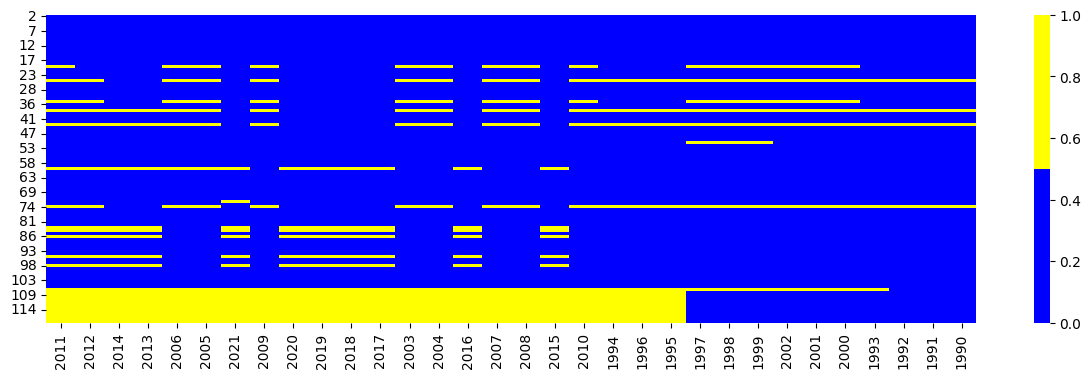

In [10]:
# Смотрим количество пропусков в данных.
cols_null_percent = child_mortality_rural.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    child_mortality_rural[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [11]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = child_mortality_rural.shape[1] #число признаков.
child_mortality_rural = child_mortality_rural.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
child_mortality_rural = child_mortality_rural.T.fillna(child_mortality_rural.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(child_mortality_rural.isnull().mean())

region    0.0
1990      0.0
1991      0.0
1992      0.0
1993      0.0
1994      0.0
1995      0.0
1996      0.0
1997      0.0
1998      0.0
1999      0.0
2000      0.0
2001      0.0
2002      0.0
2003      0.0
2004      0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
dtype: float64

In [12]:
child_mortality_rural.shape

(81, 33)

Число умерших на первом году жизни детей в городской местности.

In [13]:
# Таблица аналогична предыдущей. Применяем к ней те же изменения.
child_mortality_urban.nunique()

Unnamed: 0    117
Unnamed: 1      1
Unnamed: 2      1
1990          103
1991          104
1992          101
1993           96
1994           88
1995           88
1996           85
1997           89
1998           90
1999           97
2000           92
2001           92
2002           90
2003           81
2004           84
2005           79
2006           80
2007           80
2008           80
2009           75
2010           82
2011           73
2012           78
2013           83
2014           77
2015           78
2016           74
2017           72
2018           66
2019           70
2020           67
2021           66
dtype: int64

In [14]:
child_mortality_urban = child_mortality_urban.rename(columns={'Unnamed: 0': 'region'})
child_mortality_urban = child_mortality_urban.drop(['Unnamed: 1', 'Unnamed: 2'],axis=1)
child_mortality_urban.head()

,region,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Российская Федерация,23902.0,21549.0,19097.0,18106.0,17131.0,16258.0,14842.0,14034.0,13883.0,...,10843.0,10418.0,9641.0,8499.0,7860.0,6545.0,5723.0,5206.0,4573.0,4664.0
1,Центральный федеральный округ,5317.0,4734.0,4175.0,3899.0,3871.0,3631.0,3254.0,NaN,NaN,...,2789.0,2735.0,2402.0,2228.0,2146.0,1785.0,1593.0,1409.0,1153.0,1192.0
2,Белгородская область,209.0,198.0,165.0,165.0,153.0,131.0,102.0,100.0,99.0,...,84.0,68.0,62.0,68.0,72.0,43.0,40.0,23.0,25.0,34.0
3,Брянская область,198.0,195.0,200.0,176.0,157.0,125.0,116.0,135.0,107.0,...,81.0,77.0,87.0,67.0,67.0,65.0,33.0,26.0,29.0,14.0
4,Владимирская область,221.0,209.0,179.0,148.0,165.0,146.0,114.0,123.0,130.0,...,97.0,86.0,87.0,76.0,72.0,59.0,45.0,43.0,51.0,52.0


In [15]:
child_mortality_urban = dfs_drop_summ(child_mortality_urban)
child_mortality_urban = region_reduce(child_mortality_urban)

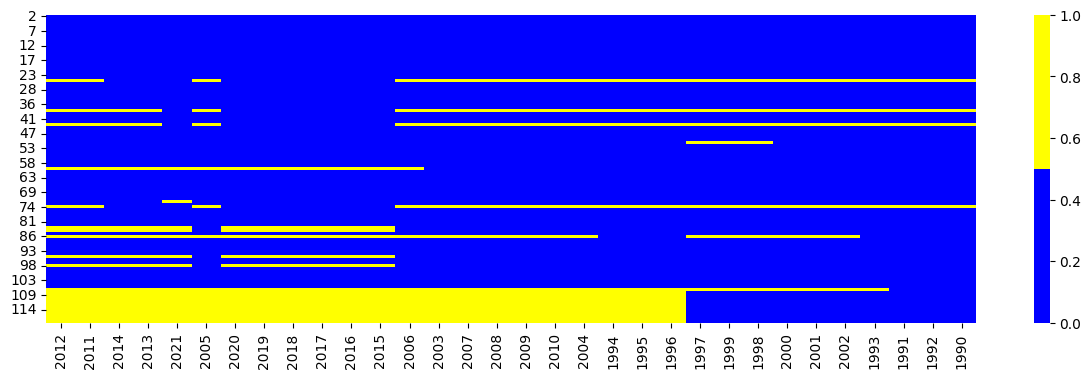

In [16]:
# Смотрим количество пропусков в данных.
cols_null_percent = child_mortality_urban.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    child_mortality_urban[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [17]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = child_mortality_urban.shape[1] #число признаков.
child_mortality_urban = child_mortality_urban.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
child_mortality_urban = child_mortality_urban.T.fillna(child_mortality_urban.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(child_mortality_urban.isnull().mean())

region    0.0
1990      0.0
1991      0.0
1992      0.0
1993      0.0
1994      0.0
1995      0.0
1996      0.0
1997      0.0
1998      0.0
1999      0.0
2000      0.0
2001      0.0
2002      0.0
2003      0.0
2004      0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
dtype: float64

In [18]:
child_mortality_urban.shape

(83, 33)

Число людей с инвалидностью по регионам

In [19]:
disabled_total_by_age.head()

,region,total,18_30,31_40,41_50,51_60,60_,date
0,Российская Федерация,11640873.0,550895.0,766054.0,1030652.0,2135436.0,7157836.0,2017-01-01
1,Центральный федеральный округ,3420310.0,118579.0,172662.0,257484.0,598102.0,2273483.0,2017-01-01
2,Белгородская область,223030.0,6318.0,10383.0,16596.0,37444.0,152289.0,2017-01-01
3,Брянская область,110418.0,4215.0,6568.0,10230.0,21481.0,67924.0,2017-01-01
4,Владимирская область,133352.0,4454.0,6811.0,9606.0,23322.0,89159.0,2017-01-01


In [20]:
# Убираем обобщающий столбец.
disabled_total_by_age.drop('total',axis=1,inplace=True)

In [21]:
# Применяем форматирующие функции.
disabled_total_by_age = dfs_drop_summ(disabled_total_by_age)
disabled_total_by_age = region_reduce(disabled_total_by_age)

In [22]:
disabled_total_by_age.shape

(5504, 7)

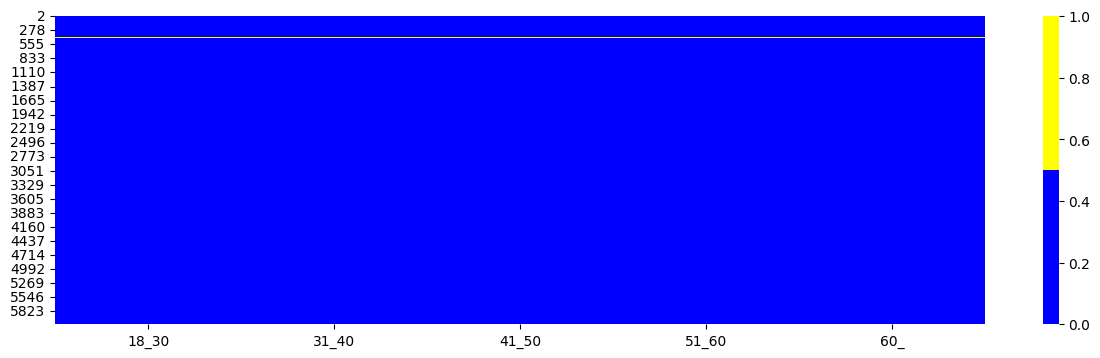

In [23]:
# Смотрим количество пропусков в данных.
cols_null_percent = disabled_total_by_age.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    disabled_total_by_age[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [24]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = disabled_total_by_age.shape[1] #число признаков.
disabled_total_by_age = disabled_total_by_age.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
disabled_total_by_age = disabled_total_by_age.T.fillna(disabled_total_by_age.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(disabled_total_by_age.isnull().mean())

region    0.0
18_30     0.0
31_40     0.0
41_50     0.0
51_60     0.0
60_       0.0
date      0.0
dtype: float64

In [25]:
# Преобразуем столбец 'date' в формат datetime
disabled_total_by_age['date'] = pd.to_datetime(disabled_total_by_age['date'], dayfirst=False)
display(disabled_total_by_age['date'])

2      2017-01-01
3      2017-01-01
4      2017-01-01
5      2017-01-01
6      2017-01-01
          ...    
6075   2022-04-01
6076   2022-04-01
6077   2022-04-01
6078   2022-04-01
6079   2022-04-01
Name: date, Length: 5498, dtype: datetime64[ns]

In [26]:
disabled_total_by_age['date'].unique()

<DatetimeArray>
['2017-01-01 00:00:00', '2017-02-01 00:00:00', '2017-03-01 00:00:00',
 '2017-04-01 00:00:00', '2017-05-01 00:00:00', '2017-06-01 00:00:00',
 '2017-07-01 00:00:00', '2017-08-01 00:00:00', '2017-09-01 00:00:00',
 '2017-10-01 00:00:00', '2017-11-01 00:00:00', '2017-12-01 00:00:00',
 '2018-01-01 00:00:00', '2018-02-01 00:00:00', '2018-03-01 00:00:00',
 '2018-04-01 00:00:00', '2018-05-01 00:00:00', '2018-06-01 00:00:00',
 '2018-07-01 00:00:00', '2018-08-01 00:00:00', '2018-09-01 00:00:00',
 '2018-10-01 00:00:00', '2018-11-01 00:00:00', '2018-12-01 00:00:00',
 '2019-01-01 00:00:00', '2019-02-01 00:00:00', '2019-03-01 00:00:00',
 '2019-04-01 00:00:00', '2019-05-01 00:00:00', '2019-06-01 00:00:00',
 '2019-07-01 00:00:00', '2019-08-01 00:00:00', '2019-09-01 00:00:00',
 '2019-10-01 00:00:00', '2019-11-01 00:00:00', '2019-12-01 00:00:00',
 '2020-01-01 00:00:00', '2020-02-01 00:00:00', '2020-03-01 00:00:00',
 '2020-04-01 00:00:00', '2020-05-01 00:00:00', '2020-06-01 00:00:00',
 '20

In [27]:
# Для последующего объединения таблиц потребуется преобразовать таблицу в общему виду.
# Группируем данные по годам, а именно по январю.
disabled_total_by_age_2017 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2017-01-01').drop(columns='date').dropna()
disabled_total_by_age_2018 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2018-01-01').drop(columns='date').dropna()
disabled_total_by_age_2019 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2019-01-01').drop(columns='date').dropna()
disabled_total_by_age_2020 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2020-01-01').drop(columns='date').dropna()
disabled_total_by_age_2021 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2021-01-01').drop(columns='date').dropna()
disabled_total_by_age_2022 = disabled_total_by_age.where(disabled_total_by_age['date'] == '2022-01-01').drop(columns='date').dropna()
# Создаём список суффиксов для последующего объединения.
suffixes=['_2017','_2018','_2019','_2020','_2021','_2022']

list_to_merge = [disabled_total_by_age_2017,disabled_total_by_age_2018,
                 disabled_total_by_age_2019,disabled_total_by_age_2020,
                 disabled_total_by_age_2021,disabled_total_by_age_2022]
# Помечаем столбцы суффиксами, кроме столбцов 'region'.
list_to_merge = [list_to_merge[i].add_suffix(suffixes[i]) for i in range(len(list_to_merge))]
list_to_merge = [list_to_merge[i].rename(columns={f"region{suffixes[i]}":"region"}) for i in range(len(list_to_merge))]
# Объединяем сгруппированные таблицы данных.
adjusted_disabled_total_by_age = reduce(lambda left,right: pd.merge(left,right, on='region', how='outer'),list_to_merge)
adjusted_disabled_total_by_age.head()

,region,18_30_2017,31_40_2017,41_50_2017,51_60_2017,60__2017,18_30_2018,31_40_2018,41_50_2018,51_60_2018,...,18_30_2021,31_40_2021,41_50_2021,51_60_2021,60__2021,18_30_2022,31_40_2022,41_50_2022,51_60_2022,60__2022
0,Алтайский край,8930.0,13527.0,13836.0,30477.0,116205.0,8238.0,13542.0,14296.0,28529.0,...,7139.0,13358.0,16039.0,23274.0,107520.0,7308.0,13058.0,16684.0,21956.0,103545.0
1,Амурская область,3687.0,5260.0,6266.0,12679.0,41171.0,3428.0,5297.0,6263.0,11732.0,...,3241.0,5143.0,6338.0,9427.0,38004.0,3295.0,5041.0,6331.0,8689.0,36116.0
2,Архангельская область,3488.0,5159.0,6747.0,13834.0,59564.0,3276.0,5140.0,6671.0,13175.0,...,2909.0,5154.0,7067.0,11368.0,56370.0,2977.0,5063.0,7242.0,10727.0,53697.0
3,Астраханская область,3159.0,3974.0,4749.0,9136.0,23977.0,2969.0,3940.0,4730.0,8755.0,...,2685.0,4018.0,4980.0,7708.0,23379.0,2686.0,3997.0,5143.0,7487.0,22783.0
4,Белгородская область,6318.0,10383.0,16596.0,37444.0,152289.0,5808.0,10127.0,15706.0,35101.0,...,4981.0,9474.0,14917.0,28836.0,133344.0,4868.0,9121.0,14645.0,26875.0,126714.0


In [28]:
adjusted_disabled_total_by_age.shape

(86, 31)

In [29]:
# Заменяем исхордную таблицу новой.
disabled_total_by_age = adjusted_disabled_total_by_age
disabled_total_by_age.head()

,region,18_30_2017,31_40_2017,41_50_2017,51_60_2017,60__2017,18_30_2018,31_40_2018,41_50_2018,51_60_2018,...,18_30_2021,31_40_2021,41_50_2021,51_60_2021,60__2021,18_30_2022,31_40_2022,41_50_2022,51_60_2022,60__2022
0,Алтайский край,8930.0,13527.0,13836.0,30477.0,116205.0,8238.0,13542.0,14296.0,28529.0,...,7139.0,13358.0,16039.0,23274.0,107520.0,7308.0,13058.0,16684.0,21956.0,103545.0
1,Амурская область,3687.0,5260.0,6266.0,12679.0,41171.0,3428.0,5297.0,6263.0,11732.0,...,3241.0,5143.0,6338.0,9427.0,38004.0,3295.0,5041.0,6331.0,8689.0,36116.0
2,Архангельская область,3488.0,5159.0,6747.0,13834.0,59564.0,3276.0,5140.0,6671.0,13175.0,...,2909.0,5154.0,7067.0,11368.0,56370.0,2977.0,5063.0,7242.0,10727.0,53697.0
3,Астраханская область,3159.0,3974.0,4749.0,9136.0,23977.0,2969.0,3940.0,4730.0,8755.0,...,2685.0,4018.0,4980.0,7708.0,23379.0,2686.0,3997.0,5143.0,7487.0,22783.0
4,Белгородская область,6318.0,10383.0,16596.0,37444.0,152289.0,5808.0,10127.0,15706.0,35101.0,...,4981.0,9474.0,14917.0,28836.0,133344.0,4868.0,9121.0,14645.0,26875.0,126714.0


In [30]:
# Смотрим количество пропусков в данных.
cols_null_percent = disabled_total_by_age.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [31]:
disabled_total_by_age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   region      86 non-null     object
 1   18_30_2017  86 non-null     object
 2   31_40_2017  86 non-null     object
 3   41_50_2017  86 non-null     object
 4   51_60_2017  86 non-null     object
 5   60__2017    86 non-null     object
 6   18_30_2018  86 non-null     object
 7   31_40_2018  86 non-null     object
 8   41_50_2018  86 non-null     object
 9   51_60_2018  86 non-null     object
 10  60__2018    86 non-null     object
 11  18_30_2019  86 non-null     object
 12  31_40_2019  86 non-null     object
 13  41_50_2019  86 non-null     object
 14  51_60_2019  86 non-null     object
 15  60__2019    86 non-null     object
 16  18_30_2020  86 non-null     object
 17  31_40_2020  86 non-null     object
 18  41_50_2020  86 non-null     object
 19  51_60_2020  86 non-null     object
 20  60__2020    

Заболеваемость на 100 тыс.человек населения

In [32]:
morbidity_2005_2020_age_disease.nunique()

Unnamed: 0     102
Unnamed: 1      19
Unnamed: 2       4
2005          6018
2006          6077
2007          6089
2008          6119
2009          6092
2010          6092
2011          5987
2012          5775
2013          6058
2014          6215
2015          5594
2016          5582
dtype: int64

In [33]:
morbidity_2005_2020_age_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8159 entries, 0 to 8158
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8159 non-null   object 
 1   Unnamed: 1  8159 non-null   object 
 2   Unnamed: 2  8159 non-null   object 
 3   2005        6348 non-null   float64
 4   2006        6348 non-null   float64
 5   2007        6348 non-null   float64
 6   2008        6348 non-null   float64
 7   2009        6348 non-null   float64
 8   2010        6348 non-null   float64
 9   2011        6348 non-null   float64
 10  2012        5980 non-null   float64
 11  2013        6348 non-null   float64
 12  2014        6460 non-null   float64
 13  2015        6117 non-null   float64
 14  2016        6110 non-null   float64
dtypes: float64(12), object(3)
memory usage: 956.3+ KB


In [34]:
# Называем безымянные столбцы.
morbidity_2005_2020_age_disease = morbidity_2005_2020_age_disease.rename(columns={'Unnamed: 0': 'region', 'Unnamed: 1': 'morbidity', 'Unnamed: 2': 'age'})
morbidity_2005_2020_age_disease.head()

,region,morbidity,age,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Российская Федерация,"Беременность, роды и послеродовой период",0-14 лет,21.3,17.6,17.9,22.1,18.1,18.9,16.2,17.7,12.2,12.1,8.1,15.5
1,Российская Федерация,"Беременность, роды и послеродовой период",15-17 лет,1537.3,1527.5,1605.2,1681.5,1618.9,1451.3,1247.6,1229.1,1272.3,1186.5,914.0,794.0
2,Российская Федерация,"Беременность, роды и послеродовой период",18 лет и старше,6731.7,6833.5,7229.7,7516.9,8007.5,8084.4,7981.6,8141.8,8084.6,8219.9,7734.1,7278.6
3,Российская Федерация,"Беременность, роды и послеродовой период",Всего,5719.4,5861.2,6258.7,6556.6,7011.6,7085.3,6979.7,7121.5,7067.6,7145.3,6700.2,6291.1
4,Российская Федерация,Болезни глаза и его придаточного аппарата,0-14 лет,5643.4,5581.1,5760.8,5775.9,5743.6,5884.8,5931.9,6206.9,6104.5,5919.4,5910.3,5971.5


In [35]:
# Применяем форматирующие функции.
morbidity_2005_2020_age_disease = dfs_drop_summ(morbidity_2005_2020_age_disease)
morbidity_2005_2020_age_disease = region_reduce(morbidity_2005_2020_age_disease)

In [36]:
# В столбце возраста убираем обобщающие данные.
morbidity_2005_2020_age_disease = morbidity_2005_2020_age_disease.reset_index()
region_list = morbidity_2005_2020_age_disease['age']
index_counter = 0
search_word = 'Всего'
for locality in region_list:
    if locality == search_word:
        morbidity_2005_2020_age_disease = morbidity_2005_2020_age_disease.drop(labels=index_counter,axis=0)
    index_counter += 1
morbidity_2005_2020_age_disease.drop(columns='index',inplace=True )

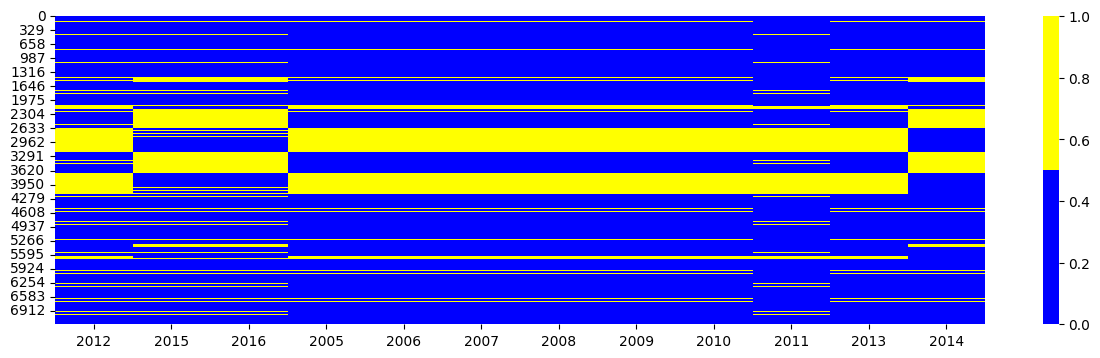

In [37]:
# Смотрим количество пропусков в данных.
cols_null_percent = morbidity_2005_2020_age_disease.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    morbidity_2005_2020_age_disease[cols].isnull(),
    cmap=sns.color_palette(colors),
)


In [38]:

#отбрасываем строки с числом пропусков более 30% (100-70).
m = morbidity_2005_2020_age_disease.shape[1] #число признаков.
morbidity_2005_2020_age_disease = morbidity_2005_2020_age_disease.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
morbidity_2005_2020_age_disease = morbidity_2005_2020_age_disease.T.fillna(morbidity_2005_2020_age_disease.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(morbidity_2005_2020_age_disease.isnull().mean())

region       0.0
morbidity    0.0
age          0.0
2005         0.0
2006         0.0
2007         0.0
2008         0.0
2009         0.0
2010         0.0
2011         0.0
2012         0.0
2013         0.0
2014         0.0
2015         0.0
2016         0.0
dtype: float64

In [39]:
morbidity_2005_2020_age_disease.head()

,region,morbidity,age,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Белгородская область,"Беременность, роды и послеродовой период",0-14 лет,21.7,10.3,10.9,2.9,26.9,12.2,46.5,69.5,0.0,3.0,5.9,0.0
1,Белгородская область,"Беременность, роды и послеродовой период",15-17 лет,1181.7,2287.8,2258.2,1704.4,2520.6,1539.2,1362.8,1437.8,980.4,1261.7,1221.4,875.6
2,Белгородская область,"Беременность, роды и послеродовой период",18 лет и старше,5249.8,5976.9,4796.6,4985.9,5791.3,5287.8,5197.0,5469.2,5373.0,5928.4,5551.7,5567.6
4,Белгородская область,Болезни глаза и его придаточного аппарата,0-14 лет,5747.6,5576.1,5538.1,5050.5,5117.5,5325.5,4968.6,5347.5,5655.3,5362.9,5841.5,6187.0
5,Белгородская область,Болезни глаза и его придаточного аппарата,15-17 лет,5690.7,6133.4,6607.8,5954.1,6234.0,6653.2,6207.1,6817.2,6891.4,7357.0,7723.9,9498.4


In [40]:
# Смотрим количество уникальных болезней в столбце.
morbidity_2005_2020_age_disease['morbidity'].nunique()

18

In [41]:
#Преобразовываем таблицу для дальнейшего объединения.
morbidity_list_to_merge = []
disease_counter = 1
# Проходим циклом по уникальным значениям в столбце 'morbidity'.
for disease in morbidity_2005_2020_age_disease['morbidity'].unique():
    age_counter = 1
    # Группируем данные по болезням. 
    disease_df = morbidity_2005_2020_age_disease.where(
        morbidity_2005_2020_age_disease['morbidity']==disease).drop(columns='morbidity').dropna()
    # Проходим по значениям возраста в новосозданных таблицах.
    for age in disease_df['age'].unique():
        df_suffix = '_'+str(disease_counter)+'_'+str(age_counter) # Создаём переменную с суффиксом.
        # Создаём новую таблицу для значения возрста и болезни.
        globals()['morbidity_2005_2020_age_disease'+df_suffix] = disease_df.where(
            disease_df['age']==age).drop(columns='age').dropna().add_suffix(df_suffix).rename(columns={f"region{df_suffix}":"region"})
        morbidity_list_to_merge.append(globals()['morbidity_2005_2020_age_disease'+df_suffix]) # дополняем список для объединения.
        age_counter += 1
    disease_counter += 1

In [42]:
# Объединяем полученные таблицы в одну.
adjusted_morbidity_2005_2020_age_disease = reduce(lambda left,right:
    pd.merge(left,right, on='region', how='outer'),morbidity_list_to_merge)
adjusted_morbidity_2005_2020_age_disease.head()

,region,2005_1_1,2006_1_1,2007_1_1,2008_1_1,2009_1_1,2010_1_1,2011_1_1,2012_1_1,2013_1_1,...,2007_18_3,2008_18_3,2009_18_3,2010_18_3,2011_18_3,2012_18_3,2013_18_3,2014_18_3,2015_18_3,2016_18_3
0,Алтайский край,4.4,1.6,6.9,14.3,20.0,11.0,11.2,7.3,1.8,...,7725.6,7913.4,7778.9,7859.8,8655.6,9851.7,10357.5,9583.1,10252.9,9288.2
1,Амурская область,47.7,12.0,21.5,36.0,23.1,42.3,9.8,39.2,0.0,...,7881.6,7929.3,7755.7,8126.6,8984.1,8633.5,8687.3,8797.8,8499.3,8364.1
2,Архангельская область,22.3,15.2,13.0,20.3,10.3,10.5,10.8,10.8,22.2,...,10765.5,10674.7,10180.2,10235.6,9539.3,10740.5,11208.5,10235.6,10235.6,10235.6
3,Астраханская область,13.2,3.6,19.2,23.9,0.0,8.3,21.8,8.7,29.9,...,7416.3,8250.3,7610.5,8193.1,7556.0,6010.4,6824.2,7610.5,7610.5,7610.5
4,Белгородская область,21.7,10.3,10.9,2.9,26.9,12.2,46.5,69.5,0.0,...,8014.7,8097.3,8118.9,8276.0,8045.9,8350.1,8312.6,8546.0,8540.9,8782.1


In [43]:
adjusted_morbidity_2005_2020_age_disease.shape

(83, 625)

In [44]:
# Заменяем значения исходной таблицы на значения новой.
morbidity_2005_2020_age_disease = adjusted_morbidity_2005_2020_age_disease

In [45]:
# Смотрим количество пропусков в данных.
cols_null_percent = disabled_total_by_age.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [46]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = disabled_total_by_age.shape[1] #число признаков.
disabled_total_by_age = disabled_total_by_age.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
disabled_total_by_age = disabled_total_by_age.T.fillna(disabled_total_by_age.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(disabled_total_by_age.isnull().mean())

region        0.0
18_30_2017    0.0
31_40_2017    0.0
41_50_2017    0.0
51_60_2017    0.0
60__2017      0.0
18_30_2018    0.0
31_40_2018    0.0
41_50_2018    0.0
51_60_2018    0.0
60__2018      0.0
18_30_2019    0.0
31_40_2019    0.0
41_50_2019    0.0
51_60_2019    0.0
60__2019      0.0
18_30_2020    0.0
31_40_2020    0.0
41_50_2020    0.0
51_60_2020    0.0
60__2020      0.0
18_30_2021    0.0
31_40_2021    0.0
41_50_2021    0.0
51_60_2021    0.0
60__2021      0.0
18_30_2022    0.0
31_40_2022    0.0
41_50_2022    0.0
51_60_2022    0.0
60__2022      0.0
dtype: float64

In [47]:
morbidity_2005_2020_age_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Columns: 625 entries, region to 2016_18_3
dtypes: object(625)
memory usage: 405.4+ KB


Процент людей, живущих за чертой бедности

In [48]:
poverty_percent_by_regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2339 entries, 0 to 2338
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           2339 non-null   object 
 1   year             2339 non-null   int64  
 2   poverty_percent  2339 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 54.9+ KB


In [49]:
# Применяем форматирующие функции.
poverty_percent_by_regions = dfs_drop_summ(poverty_percent_by_regions)
poverty_percent_by_regions = region_reduce(poverty_percent_by_regions)

In [50]:
# Смотрим уникальные значения в столбце года.
poverty_percent_by_regions['year'].nunique()

26

In [51]:
# Смотрим количество пропусков в данных.
cols_null_percent = poverty_percent_by_regions.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [52]:
# Преобразуем таблицу в общему виду.
poverty_list_to_merge = []
# Проходим по уникальным значениям столбца 'year'
for year in poverty_percent_by_regions['year'].unique():
    poverty_suffix = '_'+str(year)
    # Создём новые таблицы.
    globals()['poverty_percent_by_regions'+poverty_suffix] = poverty_percent_by_regions.where(
        poverty_percent_by_regions['year']==year).drop(columns='year').dropna().add_suffix(poverty_suffix).rename(
            columns={f"region{poverty_suffix}":"region"})
    poverty_list_to_merge.append(globals()['poverty_percent_by_regions'+poverty_suffix]) # Дополняем список.

In [53]:
# Объединяем новые таблицы в одну.
adjusted_poverty_percent_by_regions = reduce(lambda left,right: 
    pd.merge(left,right, on='region', how='outer'),poverty_list_to_merge)
adjusted_poverty_percent_by_regions.head()

,region,poverty_percent_1995,poverty_percent_1996,poverty_percent_1997,poverty_percent_1998,poverty_percent_1999,poverty_percent_2000,poverty_percent_2001,poverty_percent_2002,poverty_percent_2003,...,poverty_percent_2011,poverty_percent_2012,poverty_percent_2013,poverty_percent_2014,poverty_percent_2015,poverty_percent_2016,poverty_percent_2017,poverty_percent_2018,poverty_percent_2019,poverty_percent_2020
0,Алтайский край,33.7,46.8,45.7,52.9,53.8,53.9,47.3,38.9,33.9,...,22.6,20.6,17.6,17.1,18.0,17.8,17.5,17.4,17.6,17.5
1,Амурская область,36.1,28.2,26.3,31.2,38.0,47.7,45.3,44.6,35.6,...,20.4,16.0,16.2,14.8,15.2,17.0,16.7,15.6,15.7,15.2
2,Архангельская область,26.2,26.8,23.9,31.6,42.6,33.5,27.4,26.5,23.5,...,14.4,13.2,14.6,14.8,16.5,15.2,14.3,13.5,13.6,12.8
3,Архангельская область (без АО),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,13.0,14.5,14.5,16.2,14.9,13.9,12.5,12.7,12.3
4,Астраханская область,32.3,30.7,25.0,30.4,36.0,33.4,31.1,26.2,22.9,...,14.2,12.5,11.8,12.0,14.2,16.1,15.5,15.1,15.5,15.6


In [54]:
adjusted_poverty_percent_by_regions.shape

(87, 27)

In [55]:
# Заменяем значения исходной таблицы на новые.
poverty_percent_by_regions = adjusted_poverty_percent_by_regions

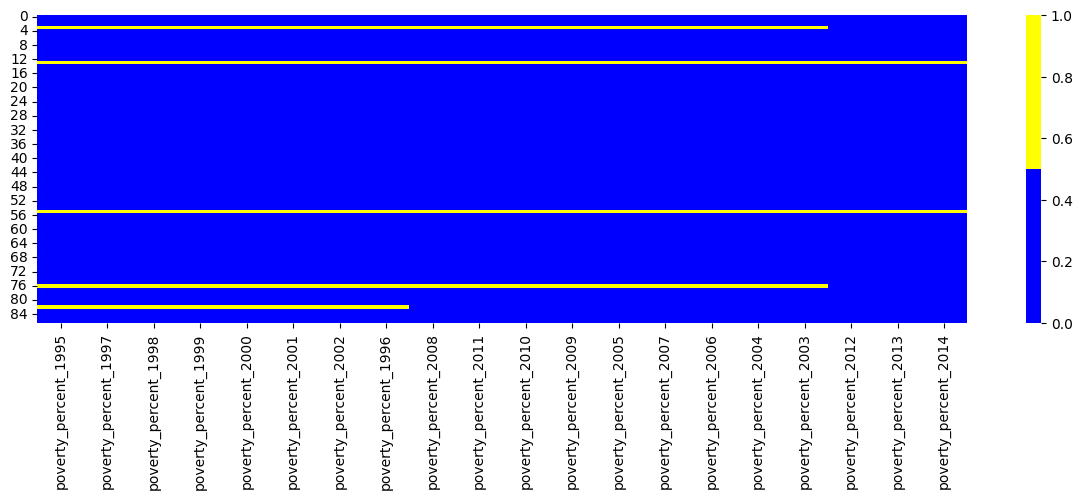

In [56]:
# Смотрим количество пропусков в данных.
cols_null_percent = poverty_percent_by_regions.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    poverty_percent_by_regions[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [57]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = poverty_percent_by_regions.shape[1] #число признаков.
poverty_percent_by_regions = poverty_percent_by_regions.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
poverty_percent_by_regions = poverty_percent_by_regions.T.fillna(poverty_percent_by_regions.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(poverty_percent_by_regions.isnull().mean())

region                  0.0
poverty_percent_1995    0.0
poverty_percent_1996    0.0
poverty_percent_1997    0.0
poverty_percent_1998    0.0
poverty_percent_1999    0.0
poverty_percent_2000    0.0
poverty_percent_2001    0.0
poverty_percent_2002    0.0
poverty_percent_2003    0.0
poverty_percent_2004    0.0
poverty_percent_2005    0.0
poverty_percent_2006    0.0
poverty_percent_2007    0.0
poverty_percent_2008    0.0
poverty_percent_2009    0.0
poverty_percent_2010    0.0
poverty_percent_2011    0.0
poverty_percent_2012    0.0
poverty_percent_2013    0.0
poverty_percent_2014    0.0
poverty_percent_2015    0.0
poverty_percent_2016    0.0
poverty_percent_2017    0.0
poverty_percent_2018    0.0
poverty_percent_2019    0.0
poverty_percent_2020    0.0
dtype: float64

Расходы на социальную политику от общих расходов бюджета региона

In [58]:
welfare_expense_share.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  94 non-null     object 
 1   2015    86 non-null     float64
 2   2016    86 non-null     float64
 3   2017    86 non-null     float64
 4   2018    86 non-null     float64
 5   2019    86 non-null     float64
 6   2020    86 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.3+ KB


In [59]:
# Применяем форматирующие функции.
welfare_expense_share = dfs_drop_summ(welfare_expense_share)
welfare_expense_share = region_reduce(welfare_expense_share)

In [60]:
# Смотрим количество пропусков в данных.
cols_null_percent = welfare_expense_share.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [61]:
welfare_expense_share.shape

(85, 7)

Среднедушевые денежные доходы населения

In [62]:
per_capita_cash_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  98 non-null     object 
 1   2015    96 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.5+ KB


In [63]:
# Применяем форматирующие функции.
per_capita_cash_income = dfs_drop_summ(per_capita_cash_income)
per_capita_cash_income = region_reduce(per_capita_cash_income)

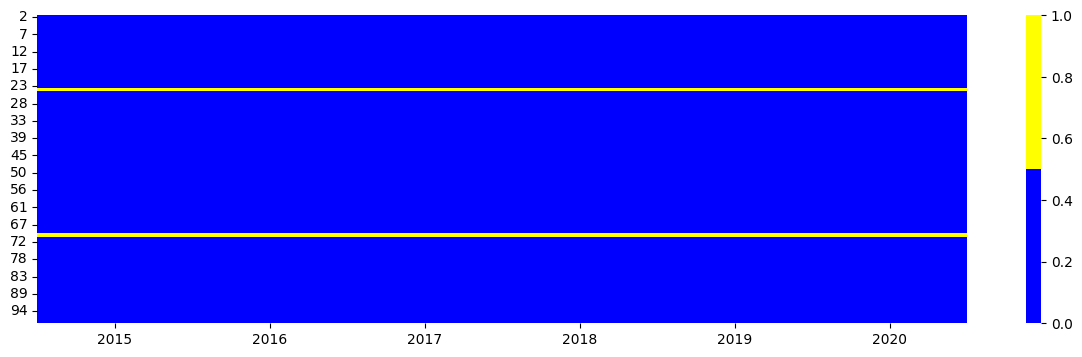

In [64]:
# Смотрим количество пропусков в данных.
cols_null_percent = per_capita_cash_income.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    per_capita_cash_income[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [65]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = per_capita_cash_income.shape[1] #число признаков.
per_capita_cash_income = per_capita_cash_income.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
per_capita_cash_income = per_capita_cash_income.T.fillna(per_capita_cash_income.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(per_capita_cash_income.isnull().mean())

region    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [66]:
per_capita_cash_income.shape

(87, 7)

In [67]:
per_capita_cash_income.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 2 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  87 non-null     object
 1   2015    87 non-null     object
 2   2016    87 non-null     object
 3   2017    87 non-null     object
 4   2018    87 non-null     object
 5   2019    87 non-null     object
 6   2020    87 non-null     object
dtypes: object(7)
memory usage: 7.5+ KB


Реальные денежные доходы

In [68]:
real_incomes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  98 non-null     object 
 1   2015    94 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.5+ KB


In [69]:
# Применяем форматирующие функции.
real_incomes = dfs_drop_summ(real_incomes)
real_incomes = region_reduce(real_incomes)

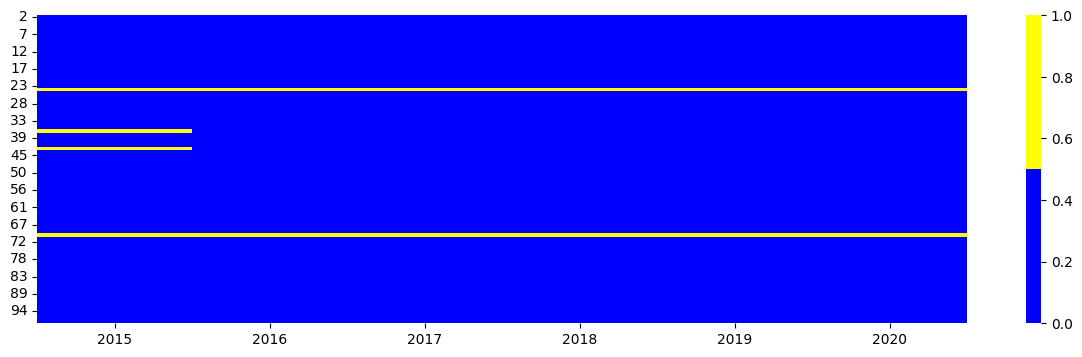

In [70]:
# Смотрим количество пропусков в данных.
cols_null_percent = real_incomes.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    real_incomes[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [71]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = real_incomes.shape[1] #число признаков.
real_incomes = real_incomes.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
real_incomes = real_incomes.T.fillna(real_incomes.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(real_incomes.isnull().mean())

region    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [72]:
real_incomes.shape

(87, 7)

Среднемесячная номинальная начисленная заработная плата

In [73]:
formal_wage_paid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  98 non-null     object 
 1   2015    96 non-null     float64
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(6), object(1)
memory usage: 5.5+ KB


In [74]:
# Применяем форматирующие функции.
formal_wage_paid = dfs_drop_summ(formal_wage_paid)
formal_wage_paid = region_reduce(formal_wage_paid)

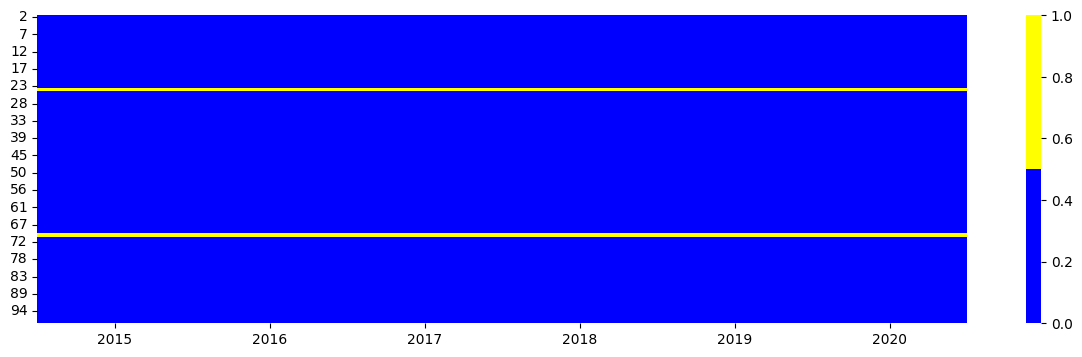

In [75]:
# Смотрим количество пропусков в данных.
cols_null_percent = formal_wage_paid.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    formal_wage_paid[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [76]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = formal_wage_paid.shape[1] #число признаков.
formal_wage_paid = formal_wage_paid.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
formal_wage_paid = formal_wage_paid.T.fillna(formal_wage_paid.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(formal_wage_paid.isnull().mean())

region    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [77]:
formal_wage_paid.shape

(87, 7)

Реальная начисленная заработная плата

In [78]:
real_pay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  98 non-null     object 
 1   2015    94 non-null     object 
 2   2016    96 non-null     float64
 3   2017    96 non-null     float64
 4   2018    96 non-null     float64
 5   2019    96 non-null     float64
 6   2020    96 non-null     float64
dtypes: float64(5), object(2)
memory usage: 5.5+ KB


In [79]:
# Применяем форматирующие функции.
real_pay = dfs_drop_summ(real_pay)
real_pay = region_reduce(real_pay)

In [80]:
# меняем формат столбца 2015 года с object на float.
real_pay[2015] = real_pay[2015].astype(float)

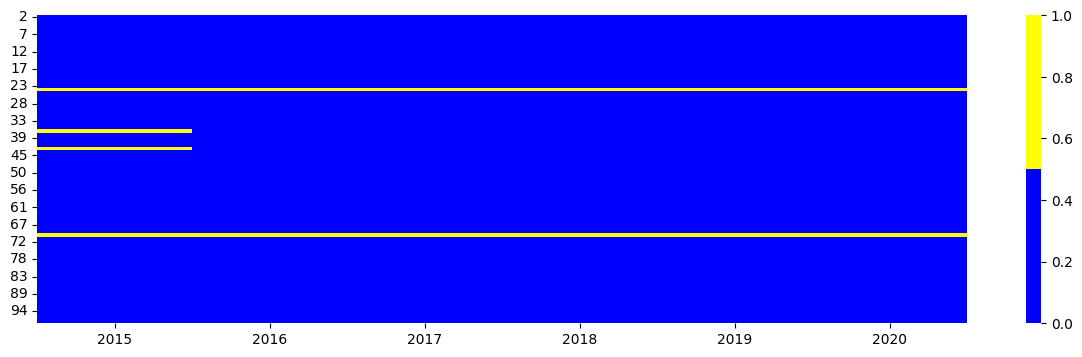

In [81]:
# Смотрим количество пропусков в данных.
cols_null_percent = real_pay.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    real_pay[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [82]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = real_pay.shape[1] #число признаков.
real_pay = real_pay.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
real_pay = real_pay.T.fillna(real_pay.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(real_pay.isnull().mean())

region    0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [83]:
real_pay.shape

(87, 7)

In [84]:
real_pay.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 2 to 97
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  87 non-null     object
 1   2015    87 non-null     object
 2   2016    87 non-null     object
 3   2017    87 non-null     object
 4   2018    87 non-null     object
 5   2019    87 non-null     object
 6   2020    87 non-null     object
dtypes: object(7)
memory usage: 7.5+ KB


Распределение малоимущего населения по социально-демографическим группам

In [85]:
poverty_socdem_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 88 non-null     object 
 1   Все население                              88 non-null     int64  
 2   Дети в возрасте до 16 лет                  88 non-null     float64
 3   Население старше трудоспособного возраста  88 non-null     float64
 4   Население трудоспособного возраста         88 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 3.6+ KB


In [86]:
# Таблицы с 2017 по 2020 год имеют аналогичную структуру. Применяем к ним одинаковые изменения.
# Переименовываем столбец без названия, убираем обобщающий столбец.
poverty_socdem_2017 = poverty_socdem_2017.rename(columns={'Unnamed: 0': 'region'})
poverty_socdem_2018 = poverty_socdem_2018.rename(columns={'Unnamed: 0': 'region'})
poverty_socdem_2019 = poverty_socdem_2019.rename(columns={'Unnamed: 0': 'region'})
poverty_socdem_2020 = poverty_socdem_2020.rename(columns={'Unnamed: 0': 'region'})
poverty_socdem_2017 = poverty_socdem_2017.drop('Все население',axis=1)
poverty_socdem_2018 = poverty_socdem_2018.drop('Все население',axis=1)
poverty_socdem_2019 = poverty_socdem_2019.drop('Все население',axis=1)
poverty_socdem_2020 = poverty_socdem_2020.drop('Все население',axis=1)
poverty_socdem_2017.head()

,region,Дети в возрасте до 16 лет,Население старше трудоспособного возраста,Население трудоспособного возраста
0,Российская Федерация,39.3,6.6,54.1
1,Белгородская область,43.4,11.8,44.8
2,Брянская область,42.9,4.9,52.2
3,Владимирская область,34.8,8.6,56.6
4,Воронежская область,38.6,5.9,55.6


In [87]:
# Применяем форматирующие функции.
poverty_socdem_2017 = dfs_drop_summ(poverty_socdem_2017)
poverty_socdem_2017 = region_reduce(poverty_socdem_2017)
poverty_socdem_2018 = dfs_drop_summ(poverty_socdem_2018)
poverty_socdem_2018 = region_reduce(poverty_socdem_2018)
poverty_socdem_2019 = dfs_drop_summ(poverty_socdem_2019)
poverty_socdem_2019 = region_reduce(poverty_socdem_2019)
poverty_socdem_2020 = dfs_drop_summ(poverty_socdem_2020)
poverty_socdem_2020 = region_reduce(poverty_socdem_2020)

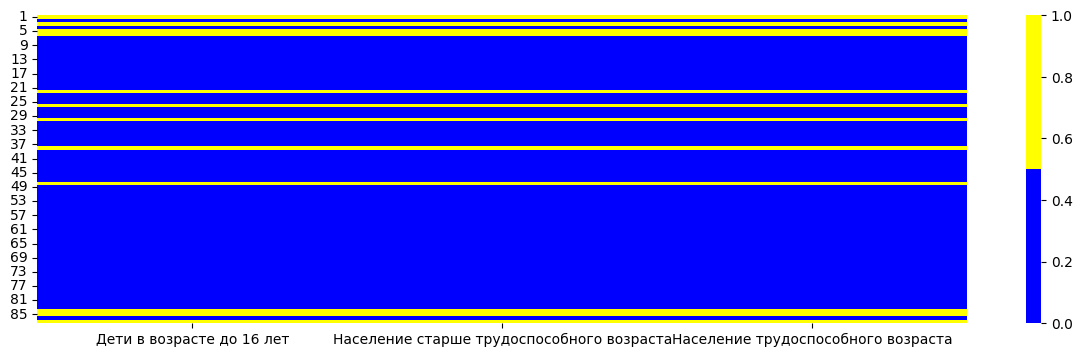

In [88]:
# Смотрим количество пропусков в данных.
cols_null_percent = poverty_socdem_2020.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    poverty_socdem_2020[cols].isnull(),
    cmap=sns.color_palette(colors),
)

Пропуски были обнружены лишь в таблице за 2020 год.

In [89]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = poverty_socdem_2020.shape[1] #число признаков.
poverty_socdem_2020 = poverty_socdem_2020.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
poverty_socdem_2020 = poverty_socdem_2020.T.fillna(poverty_socdem_2020.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(poverty_socdem_2020.isnull().mean())

region                                       0.0
Дети в возрасте до 16 лет                    0.0
Население старше трудоспособного возраста    0.0
Население трудоспособного возраста           0.0
dtype: float64

In [90]:
poverty_socdem_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 1 to 87
Data columns (total 4 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   region                                     87 non-null     object 
 1   Дети в возрасте до 16 лет                  87 non-null     float64
 2   Население старше трудоспособного возраста  87 non-null     float64
 3   Население трудоспособного возраста         87 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


In [91]:
poverty_socdem_2017.shape

(87, 4)

Характеристика жилищных условий домохозяйств

In [92]:
housing_cond.nunique()

Регион                                                                                           94
Число домохозяйств, проживающих во всех типах жилых помещений                                     1
в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности              70
в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность    67
в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность         46
затруднились ответить                                                                             8
Размер общей площади в расчете на члена домохозяйства                                            58
Размер жилой площади в расчете на члена домохозяйства                                            54
Число жилых комнат в расчете на одно домохозяйство                                               18
dtype: int64

In [93]:
# Переименовываем столбец Регион в region, убираем неинформативный столбец.
housing_cond = housing_cond.rename(columns={'Регион': 'region'})
housing_cond = housing_cond.drop('Число домохозяйств, проживающих во всех типах жилых помещений',axis=1)
housing_cond.head()

,region,"в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности","в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность","в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность",затруднились ответить,Размер общей площади в расчете на члена домохозяйства,Размер жилой площади в расчете на члена домохозяйства,Число жилых комнат в расчете на одно домохозяйство
0,Российская Федерация,80.7,15.4,3.8,0.1,24.2,16.9,2.4
1,Центральный федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Белгородская область,86.3,11.7,2.0,0.0,25.1,17.8,2.6
3,Брянская область,94.7,4.6,0.6,0.0,30.5,24.1,3.2
4,Bладимирская область,81.8,15.8,2.5,0.0,24.2,16.1,2.2


In [94]:
# Применяем форматирующие функции.
housing_cond = dfs_drop_summ(housing_cond)
housing_cond = region_reduce(housing_cond)

In [95]:
# Смотрим количество пропусков в данных.
cols_null_percent = housing_cond.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [96]:
housing_cond.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 2 to 93
Data columns (total 8 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   region                                                                                         85 non-null     object 
 1   в том числе домохозяйства, указавшие, что при проживании не испытывают стесненности            85 non-null     float64
 2   в том числе домохозяйства, указавшие, что при проживании испытывают определенную стесненность  85 non-null     float64
 3   в том числе домохозяйства, указавшие, что при проживании испытывают большую стесненность       85 non-null     float64
 4   затруднились ответить                                                                          85 non-null     float64
 5   Размер общей площади в расчете

In [97]:
housing_cond.shape

(85, 8)

In [98]:
# Переименовываем столбец Регион в region, убираем неинформативный столбец.
housing_intent = housing_intent.rename(columns={'Регион': 'region'})
housing_intent = housing_intent.drop('Все домохозяйства',axis=1)

In [99]:
housing_intent['region'].describe

<bound method NDFrame.describe of 0                                  Российская Федерация
1                         Центральный федеральный округ
2                                  Белгородская область
3                                      Брянская область
4                                  Bладимирская область
                            ...                        
91                                  Сахалинская область
92                               Еврейская авт. область
93                                 Чукотский авт. округ
94                                                  NaN
95    * здесь и далее - отметка " … " (многоточие) о...
Name: region, Length: 96, dtype: object>

In [100]:
# Находим аномальные значения.
housing_intent.iloc[-1]

region                                                                                                                                                                         * здесь и далее - отметка " … " (многоточие) о...
из них домохозяйства, собирающиеся улучшить свои жилищные условия                                                                                                                                                            NaN
из них указавшие: на стесненность проживания                                                                                                                                                                                 NaN
из них указавшие: на плохое или очень плохое состояние жилого помещения                                                                                                                                                      NaN
из них указавшие: на плохое состояние или очень плохое состояние жилого помещения и на стесненность 

In [101]:
housing_intent.iloc[-2]

region                                                                                                                                                                         NaN
из них домохозяйства, собирающиеся улучшить свои жилищные условия                                                                                                              NaN
из них указавшие: на стесненность проживания                                                                                                                                   NaN
из них указавшие: на плохое или очень плохое состояние жилого помещения                                                                                                        NaN
из них указавшие: на плохое состояние или очень плохое состояние жилого помещения и на стесненность проживания                                                                 NaN
из числа домохозяйств, собирающихся улучшить свои жилищные условия: планируют вселиться в жилое помещение

In [102]:
# Убираем аномальные значения.
housing_intent.drop(labels=[94,95],axis=0,inplace=True)

In [103]:
# Применяем форматирующие функции.
housing_intent = dfs_drop_summ(housing_intent)
housing_intent = region_reduce(housing_intent)

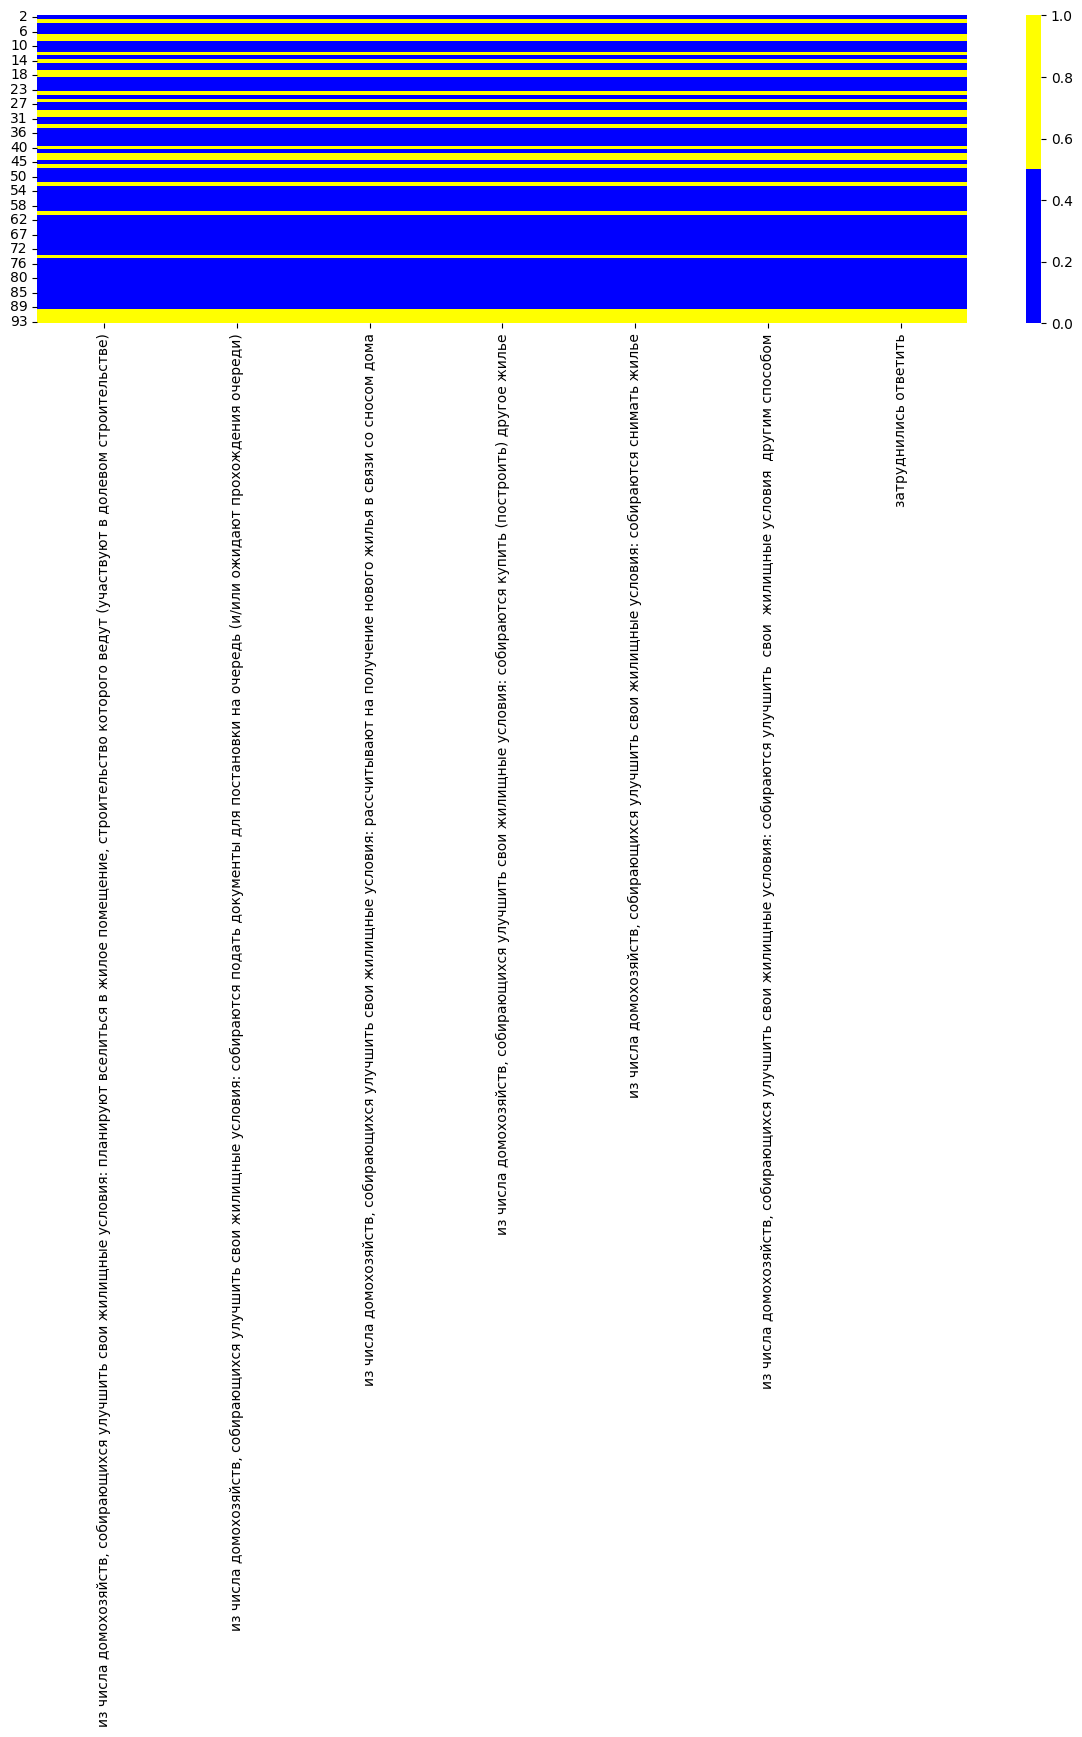

In [104]:
# Смотрим количество пропусков в данных.
cols_null_percent = housing_intent.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    housing_intent[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [105]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = housing_intent.shape[1] #число признаков.
housing_intent = housing_intent.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
housing_intent = housing_intent.T.fillna(housing_intent.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(housing_intent.isnull().mean())

region                                                                                                                                                                         0.0
из них домохозяйства, собирающиеся улучшить свои жилищные условия                                                                                                              0.0
из них указавшие: на стесненность проживания                                                                                                                                   0.0
из них указавшие: на плохое или очень плохое состояние жилого помещения                                                                                                        0.0
из них указавшие: на плохое состояние или очень плохое состояние жилого помещения и на стесненность проживания                                                                 0.0
из числа домохозяйств, собирающихся улучшить свои жилищные условия: планируют вселиться в жилое помещение

In [106]:
housing_intent.shape

(62, 13)

In [107]:
housing_intent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 2 to 89
Data columns (total 13 columns):
 #   Column                                                                                                                                                                       Non-Null Count  Dtype 
---  ------                                                                                                                                                                       --------------  ----- 
 0   region                                                                                                                                                                       62 non-null     object
 1   из них домохозяйства, собирающиеся улучшить свои жилищные условия                                                                                                            62 non-null     object
 2   из них указавшие: на стесненность проживания                                                 

Численность населения

In [108]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      368 non-null    object 
 1   Unnamed: 1      368 non-null    object 
 2   январь 1999 г.  97 non-null     float64
 3   январь 2000 г.  97 non-null     float64
 4   январь 2001 г.  97 non-null     float64
 5   январь 2002 г.  97 non-null     float64
 6   январь 2003 г.  90 non-null     float64
 7   январь 2004 г.  94 non-null     float64
 8   январь 2005 г.  94 non-null     float64
 9   январь 2006 г.  94 non-null     float64
 10  январь 2007 г.  94 non-null     float64
 11  январь 2008 г.  94 non-null     float64
 12  январь 2009 г.  94 non-null     float64
 13  январь 2010 г.  94 non-null     float64
 14  январь 2011 г.  94 non-null     float64
 15  январь 2012 г.  94 non-null     float64
 16  январь 2013 г.  94 non-null     float64
 17  январь 2014 г.  94 non-null     flo

In [109]:
population.nunique()

Unnamed: 0        257
Unnamed: 1        257
январь 1999 г.     97
январь 2000 г.     97
январь 2001 г.     97
январь 2002 г.     97
январь 2003 г.     90
январь 2004 г.     94
январь 2005 г.     94
январь 2006 г.     94
январь 2007 г.     94
январь 2008 г.     94
январь 2009 г.     94
январь 2010 г.     94
январь 2011 г.     94
январь 2012 г.     94
январь 2013 г.     94
январь 2014 г.     94
январь 2015 г.     97
январь 2016 г.    239
январь 2017 г.    237
январь 2018 г.    238
январь 2019 г.    238
январь 2020 г.    240
январь 2021 г.    242
январь 2022 г.     96
dtype: int64

In [110]:
# Переименовывыаем безымянный стобец в region, убираем неинформативный столбец.
population = population.rename(columns={'Unnamed: 0': 'region'})
population = population.drop(['Unnamed: 1'],axis=1)
population.head()

,region,январь 1999 г.,январь 2000 г.,январь 2001 г.,январь 2002 г.,январь 2003 г.,январь 2004 г.,январь 2005 г.,январь 2006 г.,январь 2007 г.,...,январь 2013 г.,январь 2014 г.,январь 2015 г.,январь 2016 г.,январь 2017 г.,январь 2018 г.,январь 2019 г.,январь 2020 г.,январь 2021 г.,январь 2022 г.
0,все население,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Российская Федерация,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Раздел 1. Муниципальные образования субъектов ...,147539426.0,146890128.0,146303611.0,145649334.0,144963650.0,144333586.0,143801046.0,143236582.0,142862692.0,...,143347059.0,143666931.0,146267288.0,146544710.0,146804372.0,146880432.0,146780720.0,146748590.0,146171015.0,145557576.0
3,Центральный федеральный округ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Раздел 1. Муниципальные образования субъектов ...,38311159.0,38227656.0,38175094.0,38068452.0,37946810.0,37965073.0,38044068.0,38109006.0,38183357.0,...,38678913.0,38819874.0,38951479.0,39104319.0,39209582.0,39311413.0,39378059.0,39433556.0,39250960.0,39104400.0


In [111]:
# Приводим таблицу к общему виду.
region_list = population['region']
index_counter = 0
# Проходжим по значениям стобца region.
for locality in region_list:
    if locality.startswith('Раздел 1') is True:
        # Заменяем значения названия региона на название предыдущего региона.
        population['region'].loc[index_counter] = population['region'].iloc[index_counter-1]
    index_counter += 1

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\1269036016.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population['region'].loc[index_counter] = population['region'].iloc[index_counter-1]
C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\1269036016.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population['region'].loc[index_counter] = population['region'].iloc[index_counter-1]
C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\1269036016.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pand

In [112]:
# Применяем форматирующие функции.
population = dfs_drop_summ(population)
population = region_reduce(population)

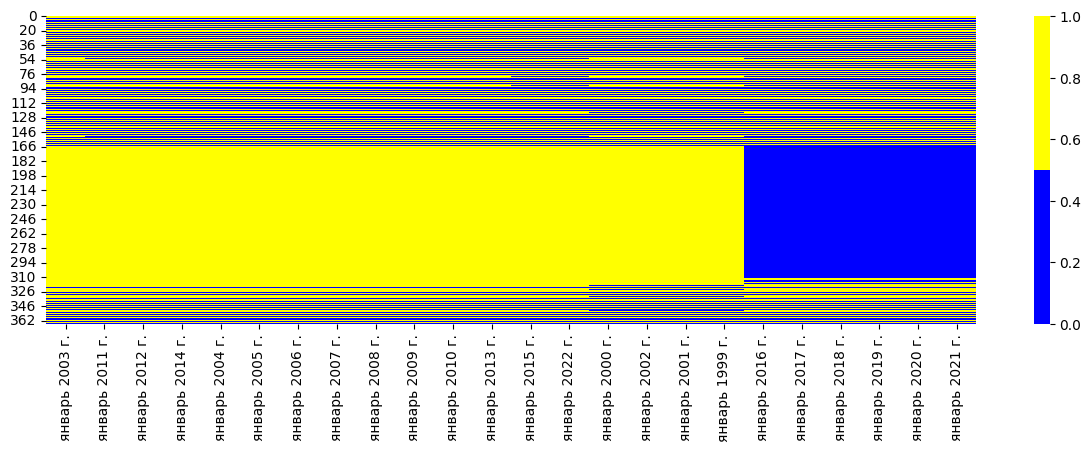

In [113]:
# Смотрим количество пропусков в данных.
cols_null_percent = population.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    population[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [114]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = population.shape[1] #число признаков.
population = population.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
population = population.T.fillna(population.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(population.isnull().mean())

region            0.0
январь 1999 г.    0.0
январь 2000 г.    0.0
январь 2001 г.    0.0
январь 2002 г.    0.0
январь 2003 г.    0.0
январь 2004 г.    0.0
январь 2005 г.    0.0
январь 2006 г.    0.0
январь 2007 г.    0.0
январь 2008 г.    0.0
январь 2009 г.    0.0
январь 2010 г.    0.0
январь 2011 г.    0.0
январь 2012 г.    0.0
январь 2013 г.    0.0
январь 2014 г.    0.0
январь 2015 г.    0.0
январь 2016 г.    0.0
январь 2017 г.    0.0
январь 2018 г.    0.0
январь 2019 г.    0.0
январь 2020 г.    0.0
январь 2021 г.    0.0
январь 2022 г.    0.0
dtype: float64

In [115]:
population.shape

(85, 25)

Валовой региональный продукт на душу населения

In [116]:
gross_regional_product.nunique()

Unnamed: 0    99
1996          81
1997          81
1998          89
1999          89
2000          89
2001          89
2002          91
2003          90
2004          90
2005          91
2006          91
2007          91
2008          91
2009          91
2010          90
2011          95
2012          95
2013          95
2014          98
2015          96
2016          96
2017          96
2018          96
2019          96
2020          96
dtype: int64

In [117]:
# Переименовываем безымянный столбец в region.
gross_regional_product = gross_regional_product.rename(columns={'Unnamed: 0': 'region'})
gross_regional_product.head()

,region,1996,1997,1998,1999,2000,2001,2002,2003,2004,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Российская Федерация,12225.0,13938.4,15371.1,26200.6,39532.3,49474.8,60611.4,74840.5,97691.9,...,317515.3,348641.5,377006.0,405147.7,449097.9,505337.7,543065.9,614333.2,646144.1,640519.0
1,Центральный федеральный округ,NaN,NaN,16564.4,31118.7,48205.0,58851.5,75739.2,94244.6,121487.7,...,417288.1,451517.2,494482.7,536607.9,580706.6,663881.8,711031.6,792780.9,835858.8,854978.5
2,Белгородская область,9575.6,10792.2,12242.8,21398.0,27969.5,33126.7,41327.4,50271.4,75629.4,...,331010.0,354570.6,368874.8,400820.8,447619.7,501467.8,539720.5,588641.5,617426.5,646569.0
3,Брянская область,7275.3,7175.7,7659.1,11752.4,17413.5,21511.9,27020.0,31953.4,37719.1,...,137187.1,164726.6,175865.0,196096.7,221080.0,258752.7,280630.1,304547.1,332442.8,347204.5
4,Владимирская область,7620.7,8431.3,9350.2,15457.1,21073.3,27170.0,32923.6,40809.4,49353.4,...,181842.6,200456.4,216320.8,232757.6,262945.5,309713.7,325043.1,349856.4,394560.3,410443.6


In [118]:
# Применяем форматирующие функции.
gross_regional_product = dfs_drop_summ(gross_regional_product)
gross_regional_product = region_reduce(gross_regional_product)

In [119]:
gross_regional_product.shape

(87, 26)

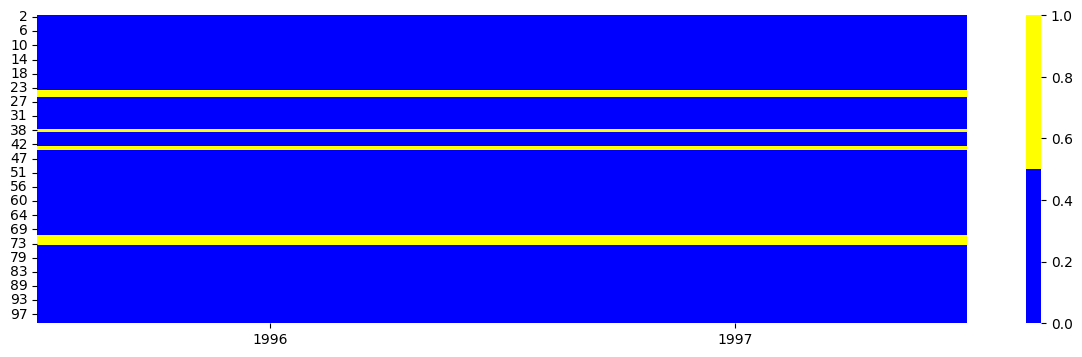

In [120]:
# Смотрим количество пропусков в данных.
cols_null_percent = gross_regional_product.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    gross_regional_product[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [121]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = gross_regional_product.shape[1] #число признаков.
gross_regional_product = gross_regional_product.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
gross_regional_product = gross_regional_product.T.fillna(gross_regional_product.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(gross_regional_product.isnull().mean())

region    0.0
1996      0.0
1997      0.0
1998      0.0
1999      0.0
2000      0.0
2001      0.0
2002      0.0
2003      0.0
2004      0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
dtype: float64

In [122]:
gross_regional_product.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87 entries, 2 to 99
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  87 non-null     object
 1   1996    87 non-null     object
 2   1997    87 non-null     object
 3   1998    87 non-null     object
 4   1999    87 non-null     object
 5   2000    87 non-null     object
 6   2001    87 non-null     object
 7   2002    87 non-null     object
 8   2003    87 non-null     object
 9   2004    87 non-null     object
 10  2005    87 non-null     object
 11  2006    87 non-null     object
 12  2007    87 non-null     object
 13  2008    87 non-null     object
 14  2009    87 non-null     object
 15  2010    87 non-null     object
 16  2011    87 non-null     object
 17  2012    87 non-null     object
 18  2013    87 non-null     object
 19  2014    87 non-null     object
 20  2015    87 non-null     object
 21  2016    87 non-null     object
 22  2017    87 non-null     object
 2

Объём отгруженных товаров собственного производства или работ/услуг, выполненных собственными силами

In [123]:
regional_production_2005_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 929 entries, 0 to 928
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            929 non-null    object 
 1   production_field  929 non-null    object 
 2   2005              740 non-null    float64
 3   2006              740 non-null    float64
 4   2007              735 non-null    float64
 5   2008              735 non-null    float64
 6   2009              708 non-null    float64
 7   2010              799 non-null    float64
 8   2011              760 non-null    float64
 9   2012              748 non-null    float64
 10  2013              717 non-null    float64
 11  2014              724 non-null    float64
 12  2015              770 non-null    float64
 13  2016              684 non-null    float64
dtypes: float64(12), object(2)
memory usage: 101.7+ KB


In [124]:
regional_production_2005_2016.head()

,region,production_field,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Российская Федерация,РАЗДЕЛ С ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ,3.062460e+09,3.720887e+09,4.488915e+09,5.271733e+09,5.090973e+09,6.217952e+09,8.020217e+09,8.950066e+09,9.213745e+09,9.690978e+09,1.125954e+10,1.173050e+10
1,Российская Федерация,Подраздел СА ДОБЫЧА ТОПЛИВНО-ЭНЕРГЕТИЧЕСКИ...,2.686256e+09,3.292691e+09,3.983633e+09,4.650669e+09,4.537654e+09,5.470740e+09,7.032308e+09,7.921745e+09,8.160342e+09,8.563862e+09,9.896535e+09,1.016955e+10
2,Российская Федерация,"Добыча каменного угля,бурого угля и торфа",2.321794e+08,2.264506e+08,2.862991e+08,4.414241e+08,3.485582e+08,5.089025e+08,6.663161e+08,6.514620e+08,6.003871e+08,6.222425e+08,7.721283e+08,9.090367e+08
3,Российская Федерация,Добыча сырой нефти и природного газа; ...,2.450541e+09,3.061557e+09,3.691794e+09,4.202276e+09,4.180328e+09,4.951480e+09,6.355953e+09,7.267043e+09,7.556542e+09,7.938532e+09,9.121647e+09,9.256097e+09
4,Российская Федерация,Добыча урановой и ториевой руд,3.535251e+06,4.683270e+06,5.540329e+06,6.968364e+06,NaN,1.035720e+07,1.003811e+07,3.240203e+06,3.413056e+06,3.087287e+06,2.759673e+06,4.420410e+06


In [125]:
# Применяем форматирующие функции.
regional_production_2005_2016 = dfs_drop_summ(regional_production_2005_2016)
regional_production_2005_2016 = region_reduce(regional_production_2005_2016)
regional_production_2017_2020 = dfs_drop_summ(regional_production_2017_2020)
regional_production_2017_2020 = region_reduce(regional_production_2017_2020)

In [126]:
regional_production_2005_2016.shape

(290, 14)

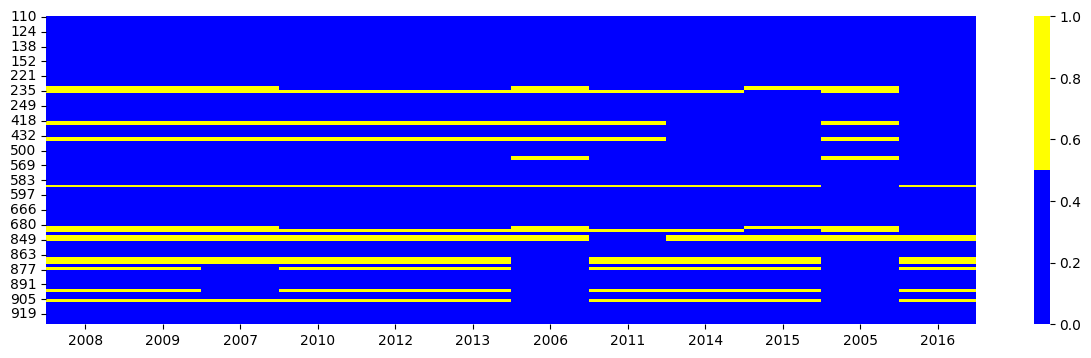

In [127]:
# Смотрим количество пропусков в данных.
cols_null_percent = regional_production_2005_2016.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    regional_production_2005_2016[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [128]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m =regional_production_2005_2016.shape[1] #число признаков.
regregional_production_2005_2016 = regional_production_2005_2016.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
regregional_production_2005_2016 = regional_production_2005_2016.T.fillna(regregional_production_2005_2016.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(regregional_production_2005_2016.isnull().mean())

region              0.000000
production_field    0.000000
2005                0.082759
2006                0.089655
2007                0.120690
2008                0.141379
2009                0.141379
2010                0.120690
2011                0.100000
2012                0.120690
2013                0.120690
2014                0.100000
2015                0.100000
2016                0.079310
dtype: float64

In [129]:
# Смотрим уникальные значения 'production_field'.
regional_production_2005_2016['production_field'].nunique()

3

In [130]:
# Приводим таблицу к общему виду.
reg_prod_05_16_list_to_merge = []
production_field_counter = 1
# Проходим по уникальным значениям 'production_field'.
for production_field in regional_production_2005_2016['production_field'].unique():
    reg_prod_05_16_suffix = '_'+str(production_field_counter)
    # Создаём новые таблицы.
    globals()['regional_production_2005_2016'+reg_prod_05_16_suffix] = regional_production_2005_2016.where(
        regional_production_2005_2016['production_field']==production_field).drop(columns='production_field').dropna().add_suffix(
            reg_prod_05_16_suffix).rename(columns={f"region{reg_prod_05_16_suffix}":"region"})
    reg_prod_05_16_list_to_merge.append(globals()['regional_production_2005_2016'+reg_prod_05_16_suffix]) # Дополняем список.
    production_field_counter += 1

In [131]:
# Объединяем новые таблицы в одну.
adjusted_regional_production_2005_2016 = reduce(lambda left,right: pd.merge(left,right, on='region', how='outer'),reg_prod_05_16_list_to_merge)
adjusted_regional_production_2005_2016.head()

,region,2005_1,2006_1,2007_1,2008_1,2009_1,2010_1,2011_1,2012_1,2013_1,...,2007_3,2008_3,2009_3,2010_3,2011_3,2012_3,2013_3,2014_3,2015_3,2016_3
0,Алтайский край,461065.8,968509.5,2238427.0,3095174.20,3383227.4,4402533.5,6.040719e+06,7.208823e+06,4068447.3,...,19258417.80,23895909.58,26748131.70,31793620.2,31991197.62,34397596.85,37720556.35,40843130.03,44355402.78,45046977.27
1,Амурская область,7941909.4,9576979.1,10649342.6,15132247.90,23995368.4,26599082.4,4.997345e+07,5.347346e+07,49746981.9,...,16757724.50,17634311.70,21774096.50,26935323.1,25888706.50,26914638.80,27547119.40,29652406.50,32521061.40,33658987.30
2,Архангельская область,43464926.7,51683344.8,78513547.2,90814537.05,141694162.1,155734027.8,1.740918e+08,1.789707e+08,184482353.9,...,18929397.20,20998990.53,24661718.67,28726812.0,30895324.47,32406301.12,34061290.24,33852958.70,35333351.50,36681740.76
3,Астраханская область,9503750.7,13370920.5,13686810.7,9319390.50,18548275.3,22508089.3,3.224568e+07,6.839286e+07,93638406.3,...,8322652.30,8129537.00,10790321.20,13237822.2,15614829.70,17150543.10,20123629.00,23623629.10,25552793.00,28401900.10
4,Белгородская область,40389903.8,41101609.9,56922776.3,62221491.50,35375249.7,73704030.2,1.101581e+08,9.439002e+07,96017055.3,...,16144094.65,17132154.30,18758086.00,22524715.5,25057795.60,25258992.30,28868066.80,27360423.80,28740007.80,28225012.75


In [132]:
adjusted_regional_production_2005_2016.shape

(82, 37)

In [133]:
# Заменяем значения исходной таблицы новыми.
regional_production_2005_2016 = adjusted_regional_production_2005_2016

In [134]:
# Смотрим количество пропусков в данных.
cols_null_percent = regional_production_2005_2016.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [135]:
regional_production_2017_2020.shape

(431, 6)

In [136]:
# Смотрим количество пропусков в данных.
cols_null_percent = regional_production_2017_2020.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)


Series([], dtype: float64)

In [137]:
# Повторяем процесс для таблицы за 2017-2020 года.
regional_production_2017_2020['production_field'].nunique()

5

In [138]:
reg_prod_17_20_list_to_merge = []
production_field_counter = 1
# Проходим по уникальным значениям 'production_field'.
for production_field in regional_production_2017_2020['production_field'].unique():
    reg_prod_17_20_suffix = '_'+str(production_field_counter)
    # Создём новые таблицы.
    globals()['regional_production_2017_2020'+reg_prod_17_20_suffix] = regional_production_2017_2020.where(
        regional_production_2017_2020['production_field']==production_field).drop(columns='production_field').dropna().add_suffix(
            reg_prod_17_20_suffix).rename(columns={f"region{reg_prod_17_20_suffix}":"region"})
    reg_prod_17_20_list_to_merge.append(globals()['regional_production_2017_2020'+reg_prod_17_20_suffix]) # Дополняем список.
    production_field_counter += 1

In [139]:
# Объединяем новые таблицы.
adjusted_regional_production_2017_2020 = reduce(lambda left,right: pd.merge(left,right, on='region', how='outer'),reg_prod_17_20_list_to_merge)
adjusted_regional_production_2017_2020.head()

,region,2017_1,2018_1,2019_1,2020_1,2017_2,2018_2,2019_2,2020_2,2017_3,...,2019_3,2020_3,2017_4,2018_4,2019_4,2020_4,2017_5,2018_5,2019_5,2020_5
0,Алтайский край,6143029.4,5023392.5,7745963.3,9146146.1,307969929.4,322810259.6,357699013.3,3.618801e+08,45806615.7,...,43900541.6,44741016.30,8068621.40,10323033.0,9813456.6,10454410.50,3.679882e+08,3.855964e+08,419158974.7,4.262217e+08
1,Амурская область,64359021.7,60169335.7,82506015.1,116722688.8,31095364.8,34091035.6,39032331.9,3.909386e+07,36087137.1,...,45166385.3,43000318.70,2880550.20,3073681.2,3308610.4,3471369.50,1.344221e+08,1.343804e+08,170013343.1,2.022882e+08
2,Архангельская область,294998009.4,385401767.4,393050127.4,286207903.7,310668820.7,247566785.6,194721562.6,2.608571e+08,36673806.3,...,38353995.2,41400918.82,5767021.60,5958788.8,6181315.5,6543248.07,6.481077e+08,6.738133e+08,632307000.7,5.950092e+08
3,Архангельская область (без АО),27140121.8,33267927.0,33553813.1,30698169.7,289234907.2,232650643.3,193168477.7,2.591439e+08,32841559.6,...,34362608.9,36359400.42,5288287.50,5493566.6,5707571.0,5852056.12,3.545049e+08,3.032356e+08,266792470.7,3.320535e+08
4,Астраханская область,226960972.4,346022363.8,339167957.3,249844173.9,53839490.4,61945738.9,76914575.7,7.602808e+07,27700172.2,...,29213093.3,29929257.80,4784234.19,6108790.8,5461715.9,6497362.30,3.132849e+08,4.418833e+08,450757342.2,3.622989e+08


In [140]:
adjusted_regional_production_2017_2020.shape

(87, 21)

In [141]:
# Заменяем исходную таблицу новой.
regional_production_2017_2020 = adjusted_regional_production_2017_2020

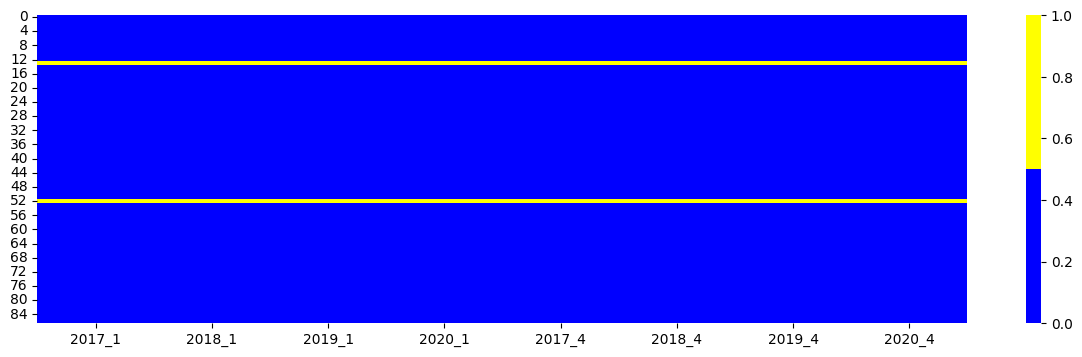

In [142]:
# Смотрим количество пропусков в данных.
cols_null_percent = regional_production_2017_2020.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    regional_production_2017_2020[cols].isnull(),
    cmap=sns.color_palette(colors),
)


In [143]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = regional_production_2017_2020.shape[1] #число признаков.
regional_production_2017_2020 = regional_production_2017_2020.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
regional_production_2017_2020 = regional_production_2017_2020.T.fillna(regional_production_2017_2020.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(regional_production_2017_2020.isnull().mean())

region    0.0
2017_1    0.0
2018_1    0.0
2019_1    0.0
2020_1    0.0
2017_2    0.0
2018_2    0.0
2019_2    0.0
2020_2    0.0
2017_3    0.0
2018_3    0.0
2019_3    0.0
2020_3    0.0
2017_4    0.0
2018_4    0.0
2019_4    0.0
2020_4    0.0
2017_5    0.0
2018_5    0.0
2019_5    0.0
2020_5    0.0
dtype: float64

In [144]:
regional_production_2005_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  82 non-null     object 
 1   2005_1  82 non-null     float64
 2   2006_1  82 non-null     float64
 3   2007_1  82 non-null     float64
 4   2008_1  82 non-null     float64
 5   2009_1  82 non-null     float64
 6   2010_1  82 non-null     float64
 7   2011_1  82 non-null     float64
 8   2012_1  82 non-null     float64
 9   2013_1  82 non-null     float64
 10  2014_1  82 non-null     float64
 11  2015_1  82 non-null     float64
 12  2016_1  82 non-null     float64
 13  2005_2  82 non-null     float64
 14  2006_2  82 non-null     float64
 15  2007_2  82 non-null     float64
 16  2008_2  82 non-null     float64
 17  2009_2  82 non-null     float64
 18  2010_2  82 non-null     float64
 19  2011_2  82 non-null     float64
 20  2012_2  82 non-null     float64
 21  2013_2  82 non-null     float64
 22  2014

In [145]:
regional_production_2017_2020.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 0 to 86
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   region  85 non-null     object
 1   2017_1  85 non-null     object
 2   2018_1  85 non-null     object
 3   2019_1  85 non-null     object
 4   2020_1  85 non-null     object
 5   2017_2  85 non-null     object
 6   2018_2  85 non-null     object
 7   2019_2  85 non-null     object
 8   2020_2  85 non-null     object
 9   2017_3  85 non-null     object
 10  2018_3  85 non-null     object
 11  2019_3  85 non-null     object
 12  2020_3  85 non-null     object
 13  2017_4  85 non-null     object
 14  2018_4  85 non-null     object
 15  2019_4  85 non-null     object
 16  2020_4  85 non-null     object
 17  2017_5  85 non-null     object
 18  2018_5  85 non-null     object
 19  2019_5  85 non-null     object
 20  2020_5  85 non-null     object
dtypes: object(21)
memory usage: 16.7+ KB


Оборот розничной торговли на душу населения

In [146]:
retail_turnover_per_capita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  108 non-null    object
 1   Unnamed: 1  108 non-null    object
 2   2000        103 non-null    object
 3   2001        103 non-null    object
 4   2002        103 non-null    object
 5   2003        97 non-null     object
 6   2004        97 non-null     object
 7   2005        97 non-null     object
 8   2006        97 non-null     object
 9   2007        97 non-null     object
 10  2008        97 non-null     object
 11  2009        97 non-null     object
 12  2010        97 non-null     object
 13  2011        97 non-null     object
 14  2012        97 non-null     object
 15  2013        97 non-null     object
 16  2014        100 non-null    object
 17  2015        101 non-null    object
 18  2016        100 non-null    object
 19  2017        99 non-null     object
 20  2018      

In [147]:
# Переименовываем безымянный столбец в region, убираем неинформативный стобец и строку.
retail_turnover_per_capita = retail_turnover_per_capita.rename(columns={'Unnamed: 0': 'region'})
retail_turnover_per_capita = retail_turnover_per_capita.drop('Unnamed: 1', axis=1)
retail_turnover_per_capita = retail_turnover_per_capita.drop(labels=[0], axis=0)
retail_turnover_per_capita.head()


,region,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
1,Российская Федерация,16046,21031,25913,31557,39166,49063,60901,76111,97688,...,149401,165051,180410,188017,192541,202568,215074,229104,231283,270606
2,Центральный федеральный округ,26062,33630,40010,46760,57011,68302,81774,97965,121934,...,188757,207394,231873,237737,243426,258278,277011,296368,301192,354141
3,Белгородская область,11820,13837,16366,19222,24168,30174,41387,55460,74599,...,129904,144992,164079,178097,192504,203298,217059,230704,237076,259151
4,Брянская область,8267,10951,14312,17988,22849,28892,36931,48448,64977,...,121136,138669,158501,177048,179767,192775,209987,225818,225643,257679
5,Владимирская область,7442,9403,10984,13357,16584,21140,29719,42497,56943,...,103848,116202,129564,139408,143643,153088,164519,175251,177680,207670


In [148]:
# Применяем форматирующие функции.
retail_turnover_per_capita.reset_index(inplace=True)
retail_turnover_per_capita = dfs_drop_summ(retail_turnover_per_capita)
retail_turnover_per_capita = region_reduce(retail_turnover_per_capita)
retail_turnover_per_capita.drop(columns=['index'],inplace=True)
retail_turnover_per_capita.head(15)

,region,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
2,Белгородская область,11820,13837,16366,19222,24168,30174,41387,55460,74599,...,129904,144992,164079,178097,192504,203298,217059,230704,237076,259151
3,Брянская область,8267,10951,14312,17988,22849,28892,36931,48448,64977,...,121136,138669,158501,177048,179767,192775,209987,225818,225643,257679
4,Владимирская область,7442,9403,10984,13357,16584,21140,29719,42497,56943,...,103848,116202,129564,139408,143643,153088,164519,175251,177680,207670
5,Воронежская область,11713,15777,18238,22189,28294,35245,39692,49708,71127,...,139133,158218,181499,198814,208638,221302,236953,251882,252416,296665
6,Ивановская область,6687,8235,10452,12413,15505,19064,26811,34985,53683,...,109822,121813,138185,143349,143568,153993,163290,178517,180314,211546
7,Калужская область,8723,12378,16855,22290,30334,38301,48173,62354,79408,...,133102,144553,161623,167204,175286,183549,194987,210454,214672,235693
8,Костромская область,9132,11182,14110,17308,22502,26448,33681,42714,56042,...,95792,104945,114959,131002,144117,150715,159014,171567,179587,217379
9,Курская область,10271,12720,15083,19014,25340,31238,41735,54693,69533,...,117703,130337,146850,160712,169082,176208,191945,206829,207134,238933
10,Липецкая область,13327,15833,18577,21782,28438,35123,44561,57819,78841,...,134049,151358,171096,186603,195514,205496,223731,241566,236552,272834
11,Московская область,14616,18499,23258,29255,42511,54721,72711,96164,128115,...,179869,191797,220314,237152,257951,280515,311893,337814,347566,422211


In [149]:
# Меняем формат столбцов, кроме region, на float.
for column in retail_turnover_per_capita:
    if column != 'region':
        retail_turnover_per_capita[column] = retail_turnover_per_capita[column].astype(float)

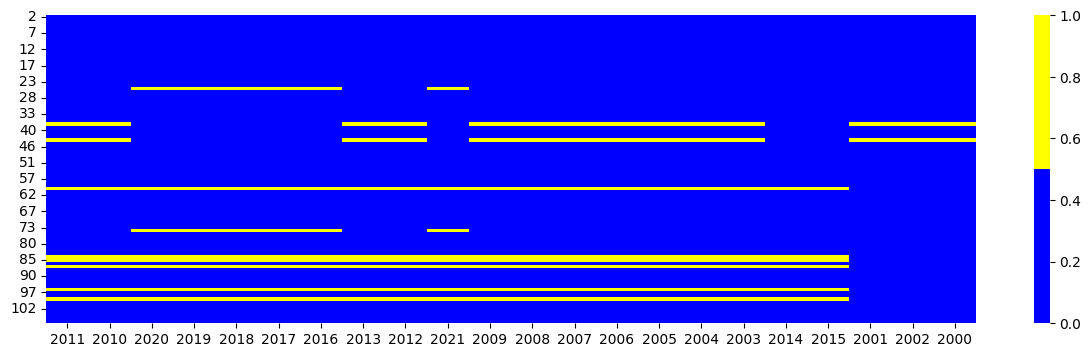

In [150]:
# Смотрим количество пропусков в данных.
cols_null_percent = retail_turnover_per_capita.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    retail_turnover_per_capita[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [151]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = retail_turnover_per_capita.shape[1] #число признаков.
retretail_turnover_per_capita = retail_turnover_per_capita.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
retretail_turnover_per_capita = retail_turnover_per_capita.T.fillna(retail_turnover_per_capita.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(retretail_turnover_per_capita.isnull().mean())

region    0.0
2000      0.0
2001      0.0
2002      0.0
2003      0.0
2004      0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
2017      0.0
2018      0.0
2019      0.0
2020      0.0
2021      0.0
dtype: float64

In [152]:
retail_turnover_per_capita.shape

(95, 23)

In [153]:
retail_turnover_per_capita.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95 entries, 2 to 106
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  95 non-null     object 
 1   2000    93 non-null     float64
 2   2001    93 non-null     float64
 3   2002    93 non-null     float64
 4   2003    87 non-null     float64
 5   2004    87 non-null     float64
 6   2005    87 non-null     float64
 7   2006    87 non-null     float64
 8   2007    87 non-null     float64
 9   2008    87 non-null     float64
 10  2009    87 non-null     float64
 11  2010    87 non-null     float64
 12  2011    87 non-null     float64
 13  2012    87 non-null     float64
 14  2013    87 non-null     float64
 15  2014    89 non-null     float64
 16  2015    89 non-null     float64
 17  2016    87 non-null     float64
 18  2017    87 non-null     float64
 19  2018    87 non-null     float64
 20  2019    87 non-null     float64
 21  2020    87 non-null     float64
 22  2021    

Сведения о заболеваемости алкоголизмом и наркоманией

In [154]:
alco0516.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  92 non-null     object 
 1   2005    92 non-null     float64
 2   2006    92 non-null     float64
 3   2007    92 non-null     float64
 4   2008    92 non-null     float64
 5   2009    92 non-null     float64
 6   2010    92 non-null     float64
 7   2011    92 non-null     float64
 8   2012    92 non-null     float64
 9   2013    92 non-null     float64
 10  2014    75 non-null     float64
 11  2015    75 non-null     float64
 12  2016    75 non-null     float64
dtypes: float64(12), object(1)
memory usage: 9.5+ KB


In [155]:
# Применяем форматирующие функции.
alco0516 = dfs_drop_summ(alco0516)
alco0516 = region_reduce(alco0516)
alco1718 = dfs_drop_summ(alco1718)
alco1718 = region_reduce(alco1718)
drug0516 = dfs_drop_summ(drug0516)
drug0516 = region_reduce(drug0516)
drug1718 = dfs_drop_summ(drug1718)
drug1718 = region_reduce(drug1718)

In [156]:
# Находим аномальные значения.
display(alco1718.iloc[-1])
display(drug1718.iloc[-1])

region    Главное медицинское управление Управления дела...
2017                                                      -
2018                                                      -
Name: 94, dtype: object

region    Главное медицинское управление Управления дела...
2017                                                      -
2018                                                      -
Name: 94, dtype: object

In [157]:
# Убираем аномальные значения.
alco1718 = alco1718.drop(labels=[94],axis=0)
drug1718 = drug1718.drop(labels=[94],axis=0)

In [158]:
# Меняем формат столбцов, кроме region, на float.
for column in alco1718:
    if column != 'region':
        alco1718[column] = alco1718[column].astype(float)
for column in drug1718:
    if column != 'region':
        drug1718[column] = drug1718[column].astype(float)

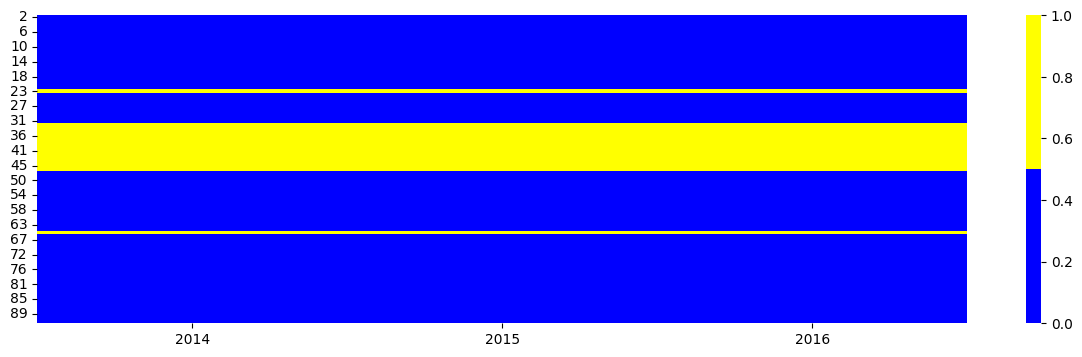

In [159]:
# Смотрим количество пропусков в данных.
cols_null_percent = alco0516.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    alco0516[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [160]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = alco0516.shape[1] #число признаков.
alco0516 = alco0516.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
alco0516 = alco0516.T.fillna(alco0516.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(alco0516.isnull().mean())

region    0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
dtype: float64

In [161]:
# Смотрим количество пропусков в данных.
cols_null_percent = alco1718.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

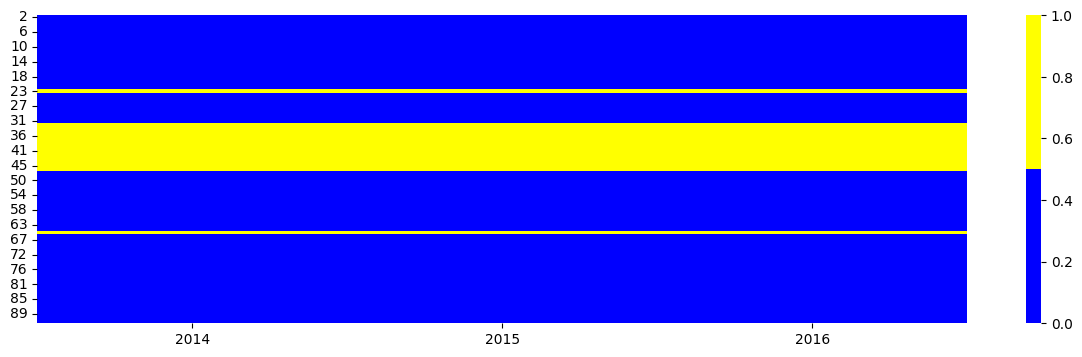

In [162]:
# Смотрим количество пропусков в данных.
cols_null_percent = drug0516.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    drug0516[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [163]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = drug0516.shape[1] #число признаков.
drug0516 = drug0516.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
drug0516 = drug0516.T.fillna(drug0516.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(drug0516.isnull().mean())

region    0.0
2005      0.0
2006      0.0
2007      0.0
2008      0.0
2009      0.0
2010      0.0
2011      0.0
2012      0.0
2013      0.0
2014      0.0
2015      0.0
2016      0.0
dtype: float64

In [164]:
# Смотрим количество пропусков в данных.
cols_null_percent = drug1718.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

Series([], dtype: float64)

In [165]:
display(alco0516.shape)
display(alco1718.shape)
display(drug0516.shape)
display(drug1718.shape)

(83, 13)

(85, 3)

(83, 13)

(85, 3)

In [166]:
drug1718.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 2 to 93
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  85 non-null     object 
 1   2017    85 non-null     float64
 2   2018    85 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.7+ KB


Рождённые в этом месяце, по регионам, без учёта мертворождённых

In [167]:
newborn.nunique()

Region             107
январь 2006 г.      91
февраль 2006 г.     92
март 2006 г.        95
апрель 2006 г.      93
                  ... 
февраль 2022 г.     96
март 2022 г.        94
апрель 2022 г.      95
май 2022 г.         95
Unnamed: 198         0
Length: 199, dtype: int64

In [168]:
# Приводим столбец регионов к общему виду, убираем пустой стобец.
newborn = newborn.rename(columns={'Region': 'region'})
newborn = newborn.drop('Unnamed: 198',axis=1)
newborn.head()

,region,январь 2006 г.,февраль 2006 г.,март 2006 г.,апрель 2006 г.,май 2006 г.,июнь 2006 г.,июль 2006 г.,август 2006 г.,сентябрь 2006 г.,...,август 2021 г.,сентябрь 2021 г.,октябрь 2021 г.,ноябрь 2021 г.,декабрь 2021 г.,январь 2022 г.,февраль 2022 г.,март 2022 г.,апрель 2022 г.,май 2022 г.
0,Российская Федерация,109422,"114068,99","129177,99","113391,99","125099,99",124238,"125926,99","140227,99","123949,99",...,"125356,99","121645,99","120080,99","114976,99","117945,99",103782,101082,115512,"99696,99",103159
1,Центральный федеральный округ,"24998,99","25539,99","29558,99",25781,29137,28837,"28997,99","31590,99","27755,99",...,"31329,99",29727,"29532,99",29093,29477,25827,25678,28086,"24979,99",26304
2,Белгородская область,1040,1094,1190,1044,1228,1249,1224,1389,1157,...,1154,1084,1053,990,1028,861,941,956,801,869
3,Брянская область,904,989,1039,936,1072,961,1058,1121,989,...,835,784,751,783,729,707,670,740,589,660
4,Владимирская область,1040,1059,1236,1063,1226,1144,1221,1333,1177,...,864,783,834,769,821,691,700,708,660,711


In [169]:
# Применяем форматирующие функции.
newborn = dfs_drop_summ(newborn)
newborn = region_reduce(newborn)

In [170]:
# Заменяем символы разделителя и формат данных, кроме region, на float.
for column in newborn:
    if column != 'region':
        newborn[column] = newborn[column].str.replace(',','.')
        newborn[column] = newborn[column].astype(float)

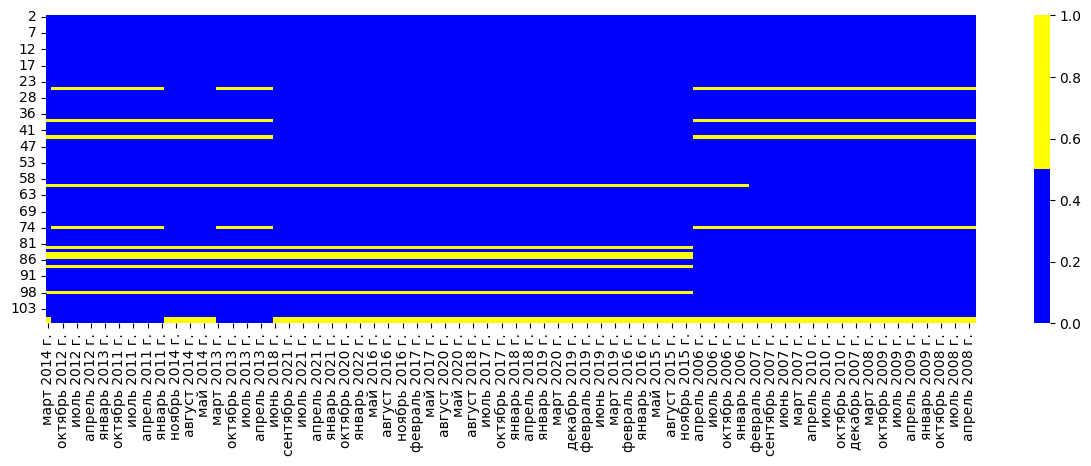

In [171]:
# Смотрим количество пропусков в данных.
cols_null_percent = newborn.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    newborn[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [172]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = newborn.shape[1] #число признаков.
newborn = newborn.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой по строке. 
newborn = newborn.T.fillna(newborn.median(axis=1,numeric_only=True)).T
# Выводим результирующую долю пропусков.
display(newborn.isnull().mean())

region             0.0
январь 2006 г.     0.0
февраль 2006 г.    0.0
март 2006 г.       0.0
апрель 2006 г.     0.0
                  ... 
январь 2022 г.     0.0
февраль 2022 г.    0.0
март 2022 г.       0.0
апрель 2022 г.     0.0
май 2022 г.        0.0
Length: 198, dtype: float64

In [173]:
newborn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 2 to 105
Columns: 198 entries, region to май 2022 г.
dtypes: object(198)
memory usage: 131.1+ KB


In [174]:
newborn.shape

(83, 198)

# <center> 2. Очистка данных </center>

После предобработки данных объединим данные в один датафрейм и проведём его базовую очистку от выбросов, пропусков и дубликатов.

In [175]:
# Объединяем все таблицы в одну.
dfs = [child_mortality_rural,child_mortality_urban,disabled_total_by_age,morbidity_2005_2020_age_disease,population,poverty_percent_by_regions,
             welfare_expense_share,per_capita_cash_income,real_incomes,formal_wage_paid,real_pay,poverty_socdem_2017,poverty_socdem_2018,
             poverty_socdem_2019,poverty_socdem_2020,housing_cond,housing_intent,gross_regional_product,regional_production_2005_2016,
             regional_production_2017_2020,retail_turnover_per_capita,alco0516,alco1718,drug0516,drug1718,newborn]
suffixes = [f"_{i}" for i in range(len(dfs))]
# Добавляем суффикс каждой таблице.
dfs = [dfs[i].add_suffix(suffixes[i]) for i in range(len(dfs))]
# Удаляем суффикс из столбцов region.
dfs = [dfs[i].rename(columns={f"region{suffixes[i]}":"region"}) for i in range(len(dfs))]
# Объединяем.
df_merged = reduce(lambda left,right: pd.merge(left,right, on='region', how='outer'), dfs)
df_merged.head()


,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,август 2021 г._25,сентябрь 2021 г._25,октябрь 2021 г._25,ноябрь 2021 г._25,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25
0,Bладимирская область,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bолгоградская область,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bологодская область,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bоронежская область,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Агинский Бурятский округ (Забайкальский край),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [176]:
df_merged.shape

(101, 1158)

In [177]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Columns: 1158 entries, region to май 2022 г._25
dtypes: float64(84), object(1074)
memory usage: 913.9+ KB


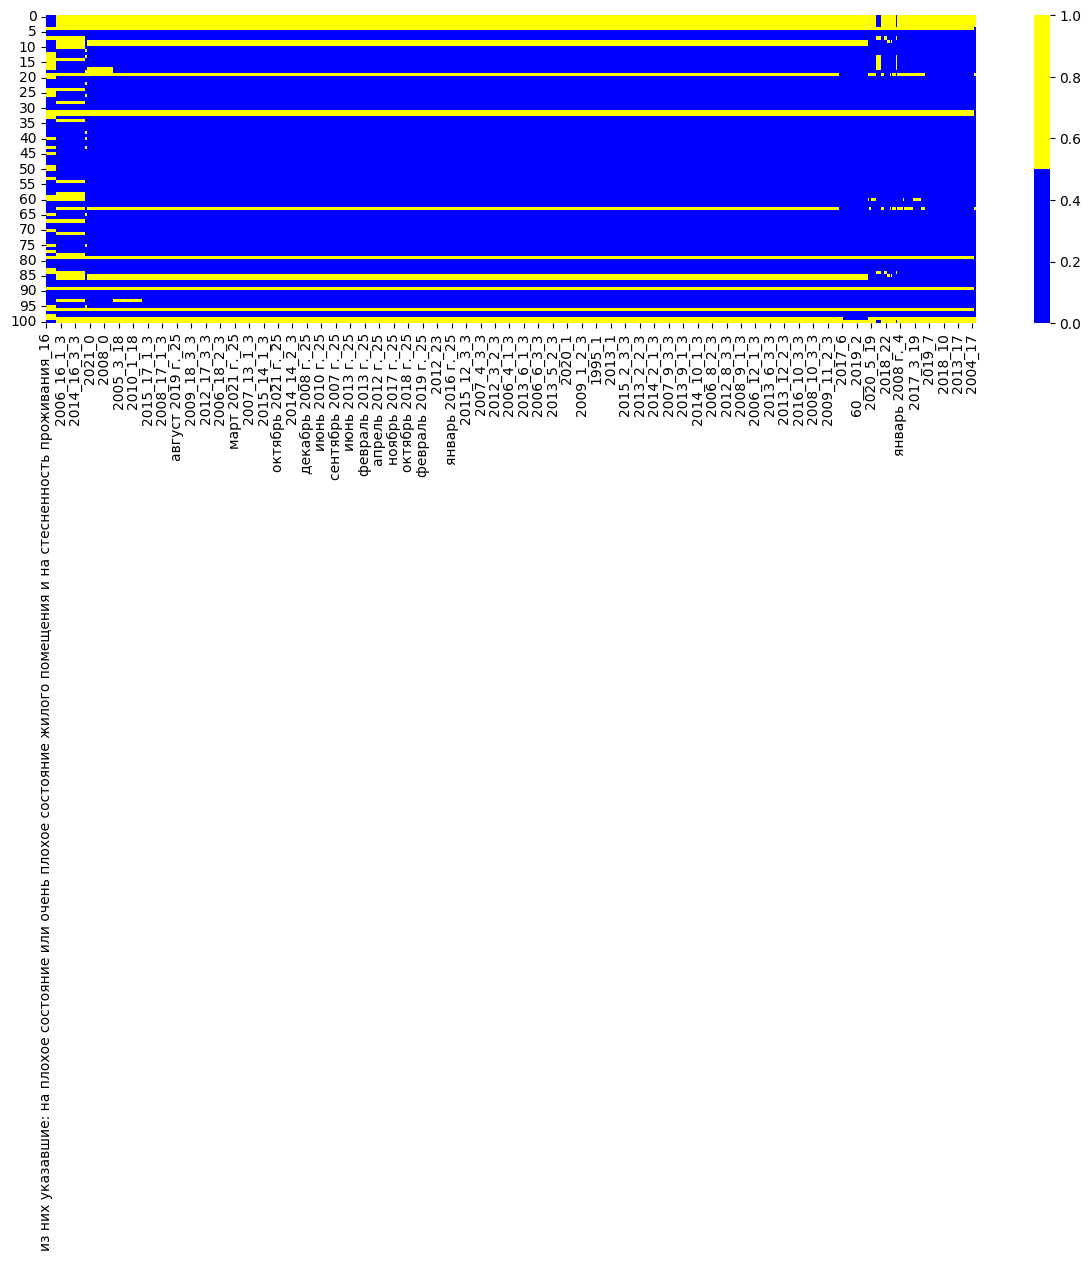

In [178]:
# Смотрим количество пропусков в данных.
cols_null_percent = df_merged.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    df_merged[cols].isnull(),
    cmap=sns.color_palette(colors),
)

После объединения в таблице появились новые пропуски. Убираем их тем же методом.

In [179]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = df_merged.shape[1] #число признаков.
df_merged = df_merged.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой. 
df_merged = df_merged.fillna(df_merged.median(numeric_only=True))
# Выводим результирующую долю пропусков.
display(df_merged.isnull().mean())

region                0.000000
1990_0                0.024096
1991_0                0.024096
1992_0                0.024096
1993_0                0.024096
                        ...   
январь 2022 г._25     0.000000
февраль 2022 г._25    0.000000
март 2022 г._25       0.000000
апрель 2022 г._25     0.000000
май 2022 г._25        0.000000
Length: 1158, dtype: float64

In [180]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 5 to 98
Columns: 1158 entries, region to май 2022 г._25
dtypes: float64(84), object(1074)
memory usage: 751.5+ KB


In [181]:
# Меняем формат столбцов, кроме region, на float.
for column in df_merged:
    if column != 'region':
        df_merged[column] = df_merged[column].astype(float)

Text(0.5, 1.0, 'Логорифмированное распределение детской смертности')

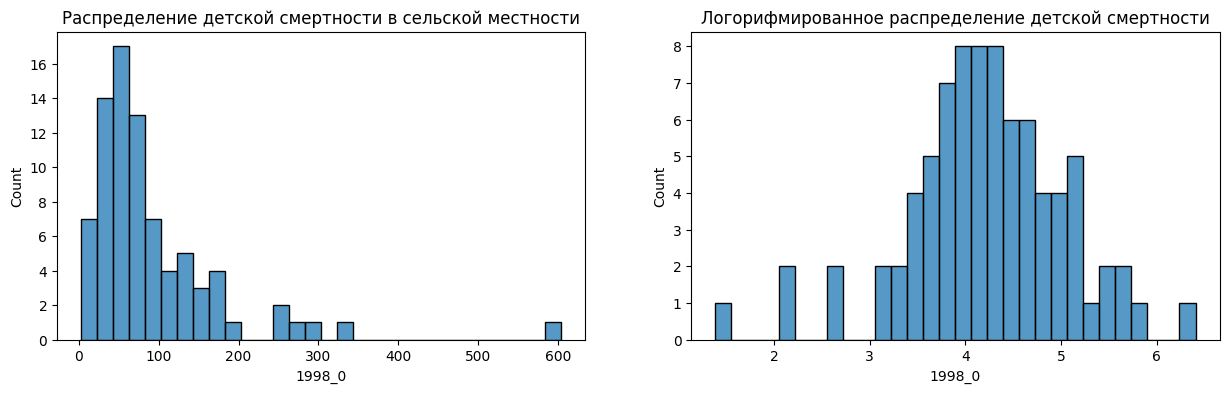

In [182]:
# Проверяем данные на нормальность.
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

#гистограмма исходного признака
histplot = sns.histplot(df_merged['1998_0'], bins=30, ax=axes[0])
histplot.set_title('Распределение детской смертности в сельской местности')

#гистограмма в логарифмическом масштабе
log_child_mortality_rural= np.log(df_merged['1998_0'] + 1)
histplot = sns.histplot(log_child_mortality_rural , bins=30, ax=axes[1])
histplot.set_title('Логорифмированное распределение детской смертности')

Можем сделть вывод, что данные в данных распеделены ненормально. Опираясь на эту информацию будем использовать в дальнейшем логарифмирование.

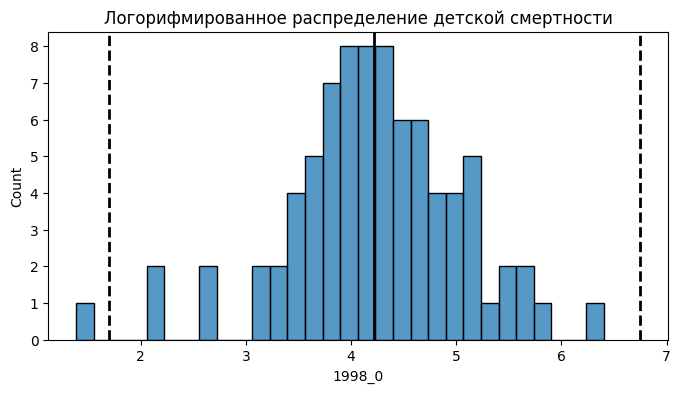

In [183]:
# Пробуем обнаружить выбросы методом z-отклонений.
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_1998_0 = np.log(df_merged['1998_0'] + 1)
histplot = sns.histplot(log_1998_0, bins=30, ax=ax)
histplot.axvline(log_1998_0.mean(), color='k', lw=2)
histplot.axvline(log_1998_0.mean()+ 3 * log_1998_0.std(), color='k', ls='--', lw=2)
histplot.axvline(log_1998_0.mean()- 3 * log_1998_0.std(), color='k', ls='--', lw=2)
histplot.set_title('Логорифмированное распределение детской смертности');

In [184]:
# Применяем к данным функцию для устранения выбросов.
for column in df_merged:
    if column != 'region':
        outliers, cleaned = outliers_z_score(df_merged, column)
        df_merged[column] = cleaned[column] # Заменяем данные на очищенные.       

Заполним пустые значения после удаления выбросов медианой.

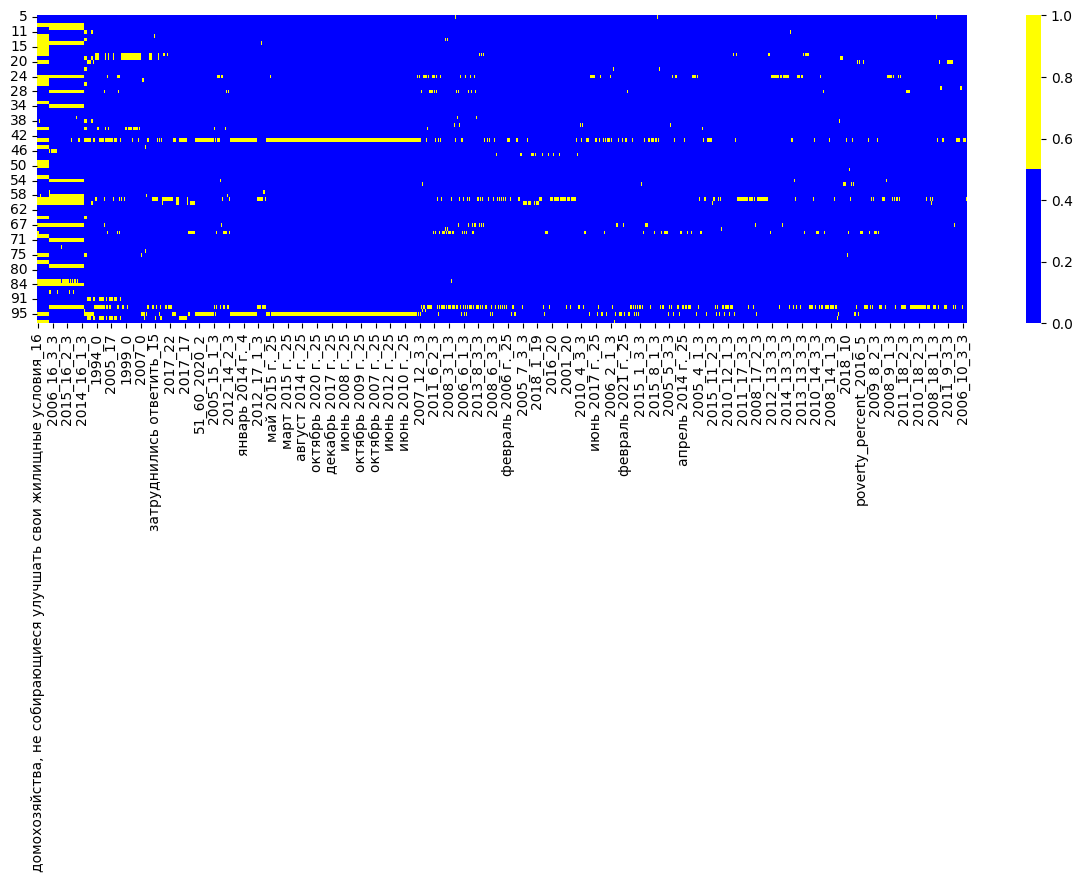

In [185]:
# Смотрим количество пропусков в данных.
cols_null_percent = df_merged.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
colors = ['blue', 'yellow'] 
fig = plt.figure(figsize=(15, 4))
cols = cols_with_null.index
ax = sns.heatmap( # Строим тепловую карту для визулизации пропусков.
    df_merged[cols].isnull(),
    cmap=sns.color_palette(colors),
)

In [186]:
#отбрасываем строки с числом пропусков более 30% (100-70).
m = df_merged.shape[1] #число признаков.
df_merged = df_merged.dropna(thresh=m*0.7, axis=0)

# Заполняем оставшиеся значения медианой. 
df_merged = df_merged.fillna(df_merged.median(numeric_only=True))
# Выводим результирующую долю пропусков.
display(df_merged.isnull().mean())

region                0.0
1990_0                0.0
1991_0                0.0
1992_0                0.0
1993_0                0.0
                     ... 
январь 2022 г._25     0.0
февраль 2022 г._25    0.0
март 2022 г._25       0.0
апрель 2022 г._25     0.0
май 2022 г._25        0.0
Length: 1158, dtype: float64

In [187]:
df_merged.shape

(83, 1158)

In [188]:
df_merged.head()

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,август 2021 г._25,сентябрь 2021 г._25,октябрь 2021 г._25,ноябрь 2021 г._25,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25
5,Алтайский край,217.0,245.0,230.0,249.0,226.0,261.0,220.0,213.0,176.0,...,1707.0,1602.0,1630.0,1564.0,1591.0,1410.0,1433.0,1540.0,1369.0,1488.0
6,Амурская область,142.0,124.0,106.0,108.0,111.0,99.0,100.0,118.0,86.0,...,654.0,619.0,615.0,546.0,617.0,592.0,527.0,634.0,529.0,534.0
7,Архангельская область,116.0,118.0,90.0,94.0,80.0,65.0,71.0,46.0,56.0,...,782.0,736.0,741.0,700.0,754.0,654.0,630.0,764.0,656.0,687.0
10,Астраханская область,103.0,73.0,55.0,63.0,62.0,71.0,57.0,79.0,92.0,...,1015.0,941.0,980.0,927.0,880.0,781.0,753.0,884.0,676.0,670.0
11,Белгородская область,103.0,92.0,75.0,79.0,80.0,72.0,72.0,67.0,61.0,...,1154.0,1084.0,1053.0,990.0,1028.0,861.0,941.0,956.0,801.0,869.0


In [189]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83 entries, 5 to 98
Columns: 1158 entries, region to май 2022 г._25
dtypes: float64(1157), object(1)
memory usage: 751.5+ KB


In [190]:
# Проверяем признак region на отсутствие дубликатов.
df_merged['region'].nunique() == df_merged.shape[0]

True

In [191]:
# Проверяем остальные данные на наличие дубликатов.
dupl_columns = list(df_merged.columns)
dupl_columns.remove('region')

mask = df_merged.duplicated(subset=dupl_columns)
df_duplicates = df_merged[mask]
print(f'Число найденных дубликатов: {df_duplicates.shape[0]}')

Число найденных дубликатов: 0


# <center> 3. Определение уязвимых групп населения </center>

## <center> 3.1 Кластеризация регионов </center>

На данном этапе переходим к постраению кластеров. Опробуем различные алгоритмы кластеризации для нахождения оптиммального.

Отделим от данных признак региона и нормализируем данные.

In [192]:
# Отделяем от данных признак region.
X = df_merged.drop('region',axis =1)  
y = df_merged['region']
col_names = list(X.columns)

# Инициализируем нормализатор RobustScaler.
r_scaler = preprocessing.RobustScaler()

# Кодируем исходный датасет.
X_scaled = r_scaler.fit_transform(X)

# Преобразуем промежуточный датасет в полноценный датафрейм.
X_scaled_df = pd.DataFrame(X_scaled, columns=col_names)


In [193]:
# Строим корреляцию.
#plt.figure(figsize = (20,10))       
#sns.heatmap(X_scaled_df.corr(),annot = True)

Сначала попробуем кластеризировать данные алгоритмов KMeans. Для этого нужно определиться с количеством кластеров.

In [194]:
# Определяем оптимальное количество кластеров с помощью коэффицента силуэта.
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state = 1)
    kmeans.fit(X_scaled)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(i, silhouette_avg)

2 0.7320932849162216
3 0.2647172432553171
4 0.2301043397669742
5 0.24468159533824058
6 0.20950823433480784
7 0.137805536073236
8 0.10238560078421943
9 0.09152592488146453
10 0.1213947790517834


Наивысшие значения для двух кластеров. Их и используем для алгоритма.

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\255764215.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['K-Means_Cluster_ID_0'] = kmeans.labels_


<AxesSubplot: xlabel='K-Means_Cluster_ID_0', ylabel='poverty_percent_2020_5'>

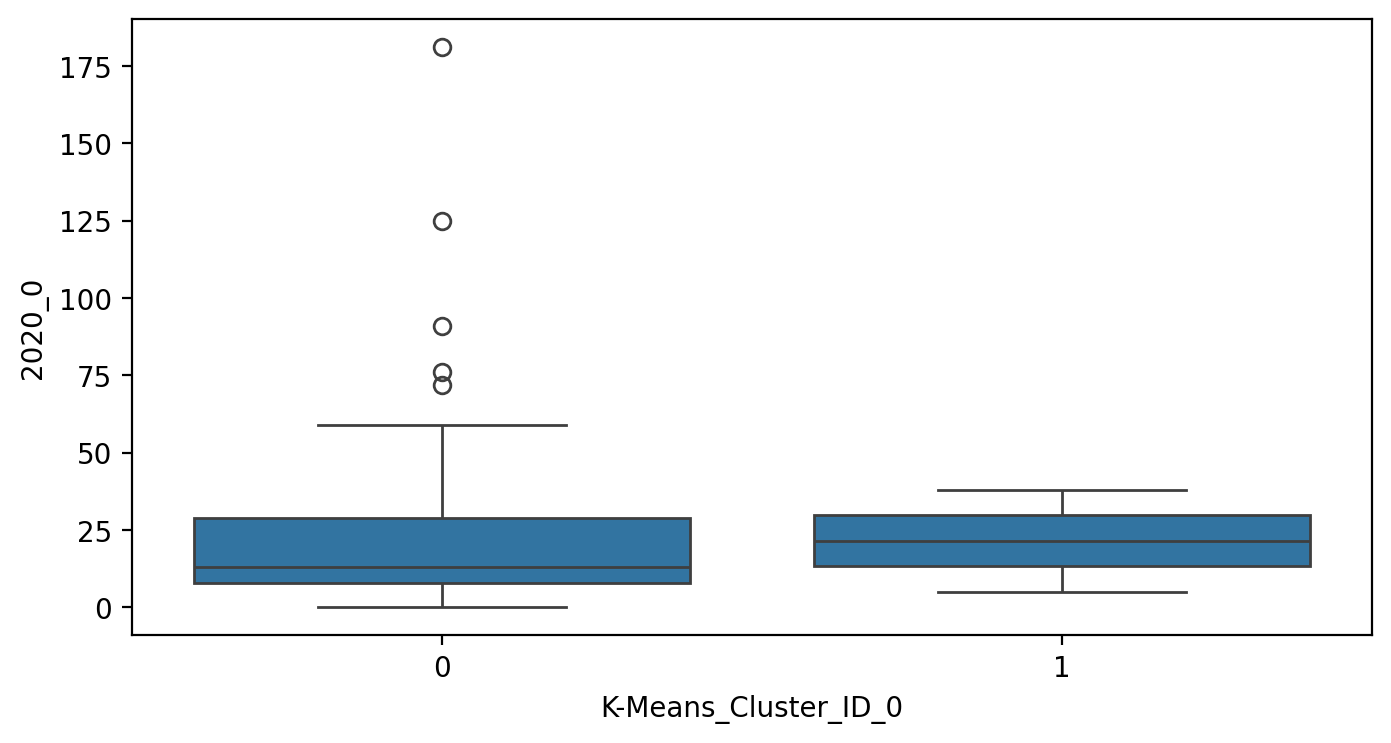

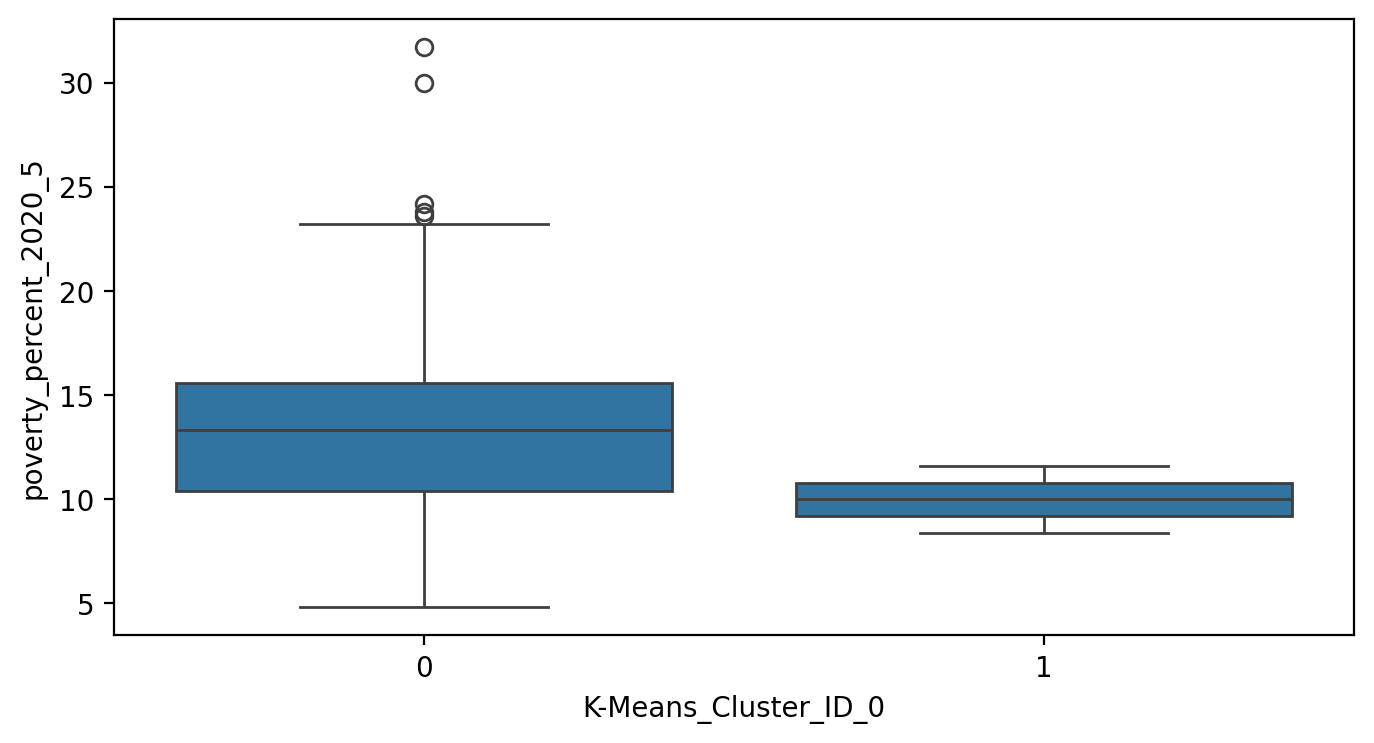

In [195]:
# Зпускаем алгоритм k-means с оптимальным количеством кластеров.
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_scaled)
df_merged['K-Means_Cluster_ID_0'] = kmeans.labels_
# Визуализируем кластеры на примере уровня бедности и детской смертности за 2020 год. 
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_0', y='2020_0', data=df_merged)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_0', y='poverty_percent_2020_5', 
            data=df_merged)   

In [196]:
K_Means_region = df_merged[df_merged['K-Means_Cluster_ID_0'] == 1]
display(K_Means_region)

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,сентябрь 2021 г._25,октябрь 2021 г._25,ноябрь 2021 г._25,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25,K-Means_Cluster_ID_0
84,Тюменская область,268.0,267.0,217.0,208.0,176.0,200.0,147.0,184.0,172.0,...,3914.0,3881.0,3744.99,3976.0,3431.0,3203.0,3888.0,3394.0,3589.0,1
91,Ханты-Мансийский АО,44.0,44.0,40.0,46.0,25.0,47.0,31.0,34.0,33.0,...,1692.0,1658.0,1621.00,1732.0,1420.0,1412.0,1714.0,1493.0,1589.0,1


Результаты нас не устраивают. Попробуем понизить размерность данных.

In [197]:
# Пробуем повысить качество клстеризации путём понижения размерности данныж с помощью PCA.
pca = PCA(n_components=0.9, random_state=42).fit(X_scaled)
len(pca.components_)

18

In [198]:
pca.explained_variance_ratio_[0]

0.41605027819597434

In [199]:
X_pca = pca.fit_transform(X_scaled)

In [200]:
# Определяем оптимальное количество кластеров с помощью коэффицента силуэта.
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state = 1)
    kmeans.fit(X_pca)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(i, silhouette_avg)

2 0.7625011806746402
3 0.32642032913430397
4 0.29570859116347564
5 0.3114871993140385
6 0.15523819350710566
7 0.15973385586807978
8 0.1572943469213085
9 0.13280773239459845
10 0.14449038675147355


Видим небольшое улучшение качества кластеризации. Оптимальное количество кластеров - 2.

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\2697108001.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['K-Means_Cluster_ID_1'] = kmeans.labels_


<AxesSubplot: xlabel='K-Means_Cluster_ID_1', ylabel='poverty_percent_2020_5'>

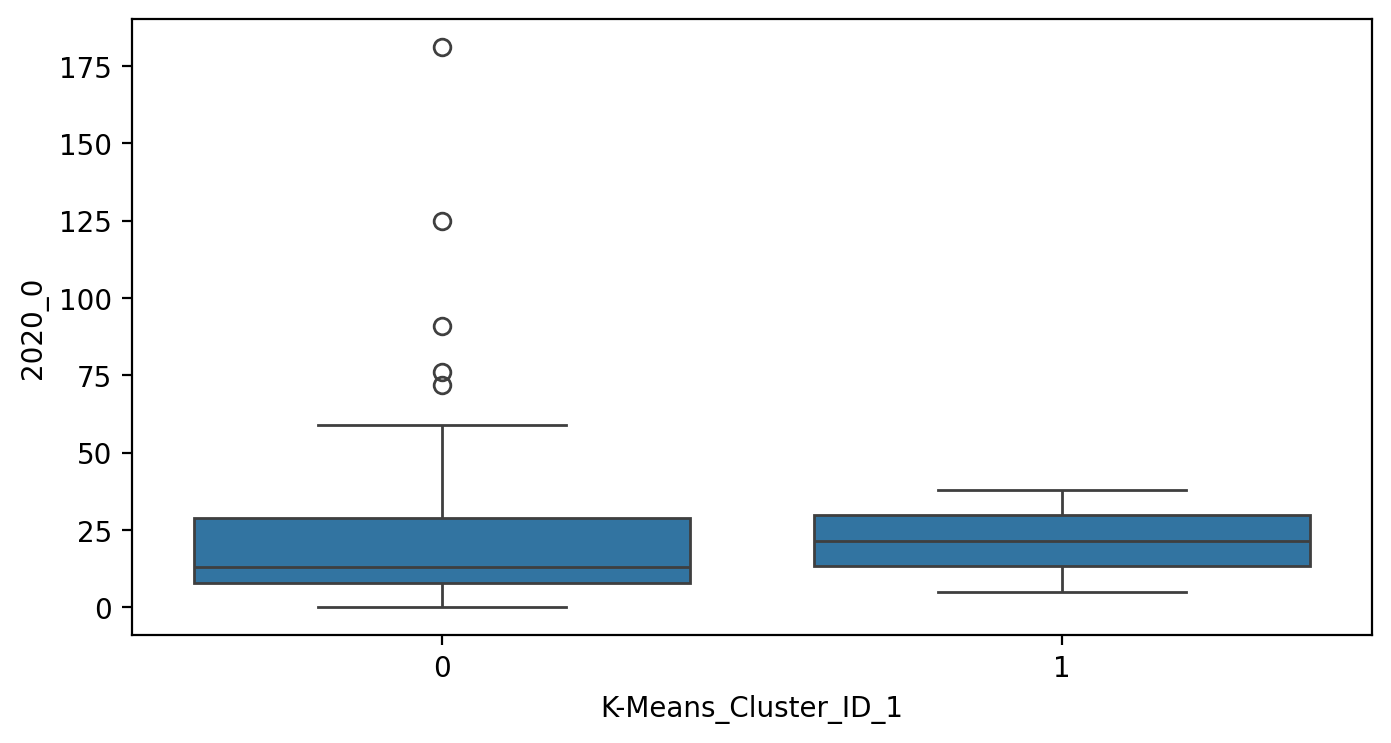

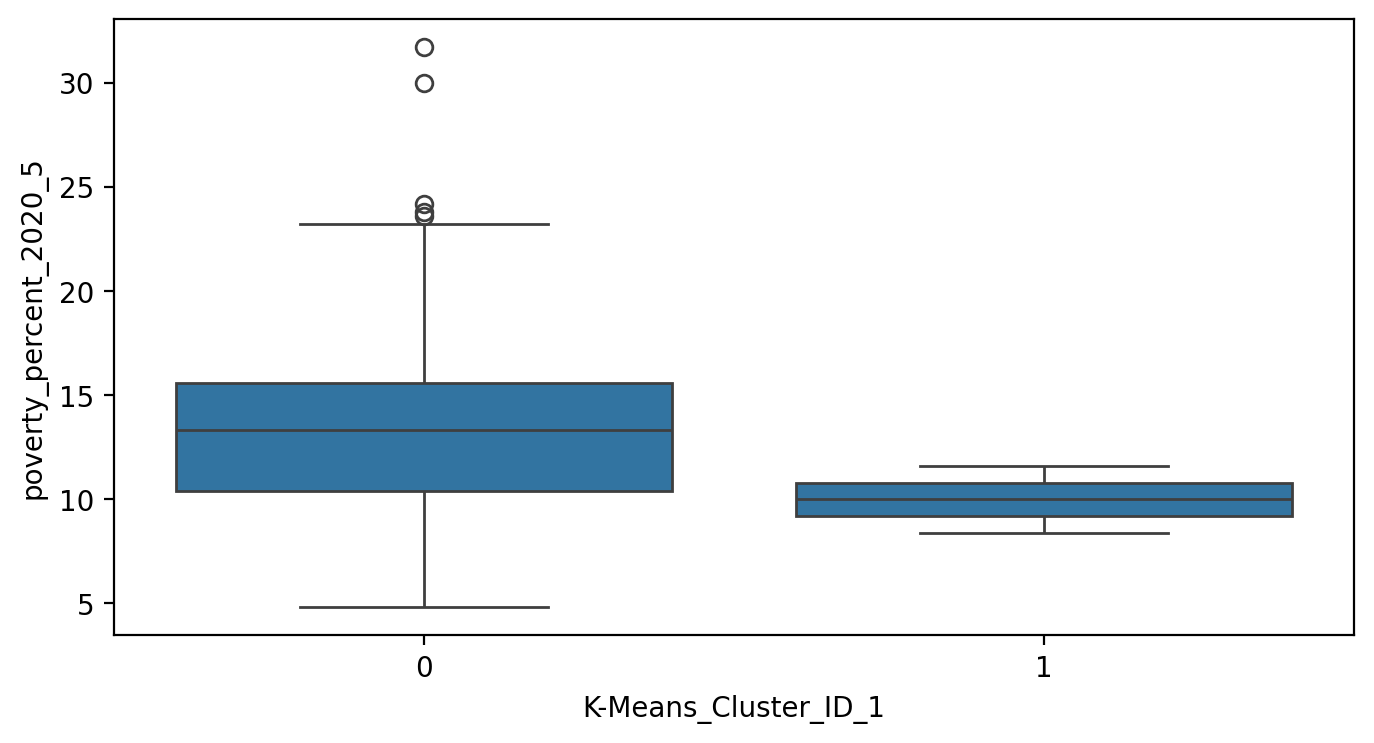

In [201]:
# Зпускаем алгоритм k-means с двумя кластерами.
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_pca)
df_merged['K-Means_Cluster_ID_1'] = kmeans.labels_
# Визуализируем кластеры на примере уровня бедности и детской смертности за 2020 год.
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_1', y='2020_0', data=df_merged)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_1', y='poverty_percent_2020_5', 
            data=df_merged)   

In [202]:
K_Means_region = df_merged[df_merged['K-Means_Cluster_ID_1'] == 0]
display(K_Means_region)

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,октябрь 2021 г._25,ноябрь 2021 г._25,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25,K-Means_Cluster_ID_0,K-Means_Cluster_ID_1
5,Алтайский край,217.0,245.0,230.0,249.0,226.0,261.0,220.0,213.0,176.0,...,1630.0,1564.0,1591.0,1410.0,1433.00,1540.0,1369.0,1488.0,0,0
6,Амурская область,142.0,124.0,106.0,108.0,111.0,99.0,100.0,118.0,86.0,...,615.0,546.0,617.0,592.0,527.00,634.0,529.0,534.0,0,0
7,Архангельская область,116.0,118.0,90.0,94.0,80.0,65.0,71.0,46.0,56.0,...,741.0,700.0,754.0,654.0,630.00,764.0,656.0,687.0,0,0
10,Астраханская область,103.0,73.0,55.0,63.0,62.0,71.0,57.0,79.0,92.0,...,980.0,927.0,880.0,781.0,753.00,884.0,676.0,670.0,0,0
11,Белгородская область,103.0,92.0,75.0,79.0,80.0,72.0,72.0,67.0,61.0,...,1053.0,990.0,1028.0,861.0,941.00,956.0,801.0,869.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,Чеченская Республика,662.0,660.0,510.0,94.0,85.0,81.5,72.5,244.0,244.0,...,2949.0,2805.0,2786.0,2639.0,2528.99,2663.0,2100.0,2349.0,0,0
94,Чувашская Республика,121.0,125.0,134.0,115.0,100.0,112.0,81.0,86.0,87.0,...,960.0,813.0,877.0,783.0,794.00,861.0,755.0,806.0,0,0
95,Чукотский автономный округ,20.0,21.0,25.0,20.0,14.0,17.0,17.0,12.0,13.0,...,54.0,813.0,875.0,753.0,716.00,57.0,681.0,747.0,0,0
97,Ямало-Hенецкий АО,58.0,48.0,33.0,44.0,38.0,42.0,39.0,45.0,41.0,...,601.0,580.0,645.0,532.0,496.99,623.0,572.0,590.0,0,0


Кластер с наиболее нуждающейся группой всё ещё слишком велик. Попробуем метод понижения рзмерности TSNE.

In [203]:
# создаём объект класса TSNE
# n_components — размерность нового пространства
tsne = TSNE(n_components=2, perplexity=5, n_iter=2000, random_state=42)
# обучаем модель на данных X и применяем к матрице X уменьшение размерности
X_tsne = tsne.fit_transform(X_scaled)

c:\Users\Aleksey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\Users\Aleksey\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


In [204]:
# Определяем оптимальное количество кластеров с помощью коэффицента силуэта.
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state = 1)
    kmeans.fit(X_tsne)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_tsne, cluster_labels)
    print(i, silhouette_avg)

2 0.5623158
3 0.4841675
4 0.4840645
5 0.4643492
6 0.452158
7 0.48717898
8 0.47445458
9 0.46962136
10 0.45936516


Качество уменьшилось. Оптимальное количество кластеров всё ещё два.

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\4172428816.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['K-Means_Cluster_ID_2'] = kmeans.labels_


<AxesSubplot: xlabel='K-Means_Cluster_ID_2', ylabel='poverty_percent_2020_5'>

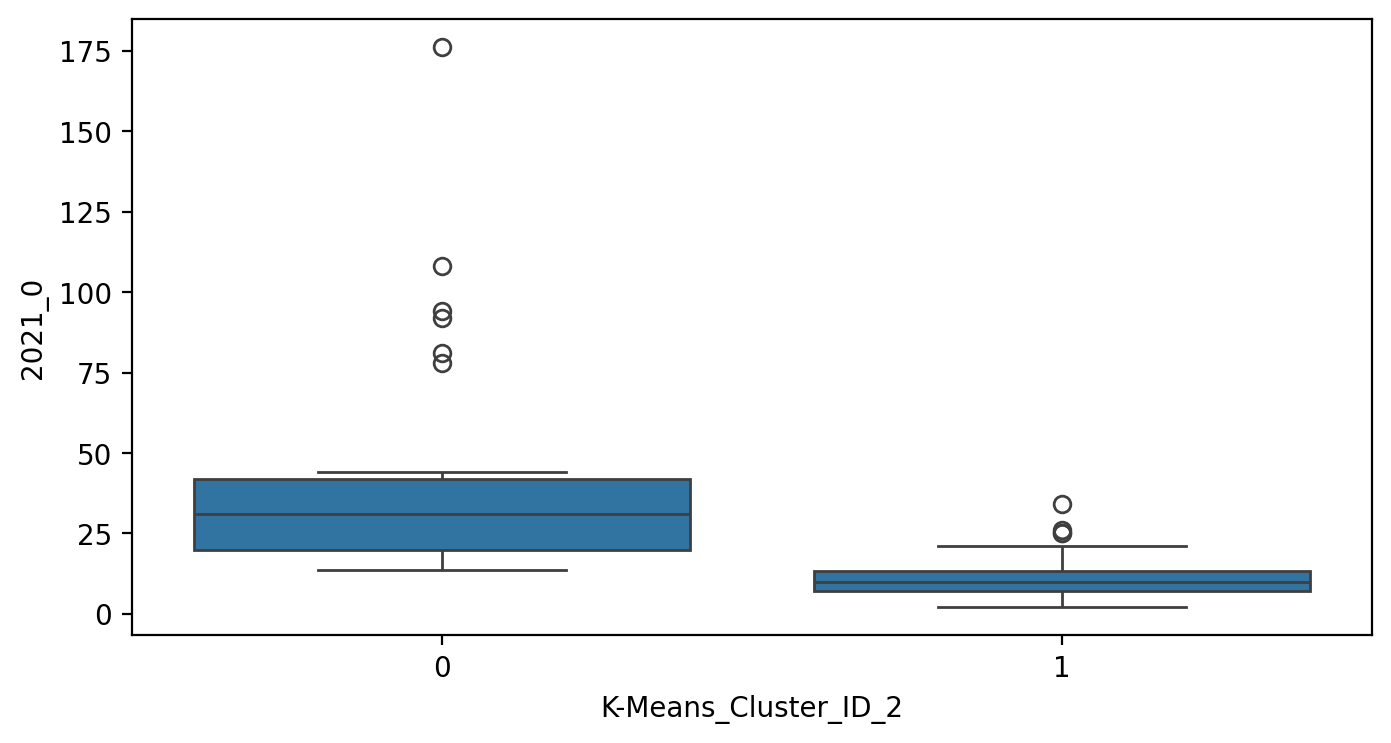

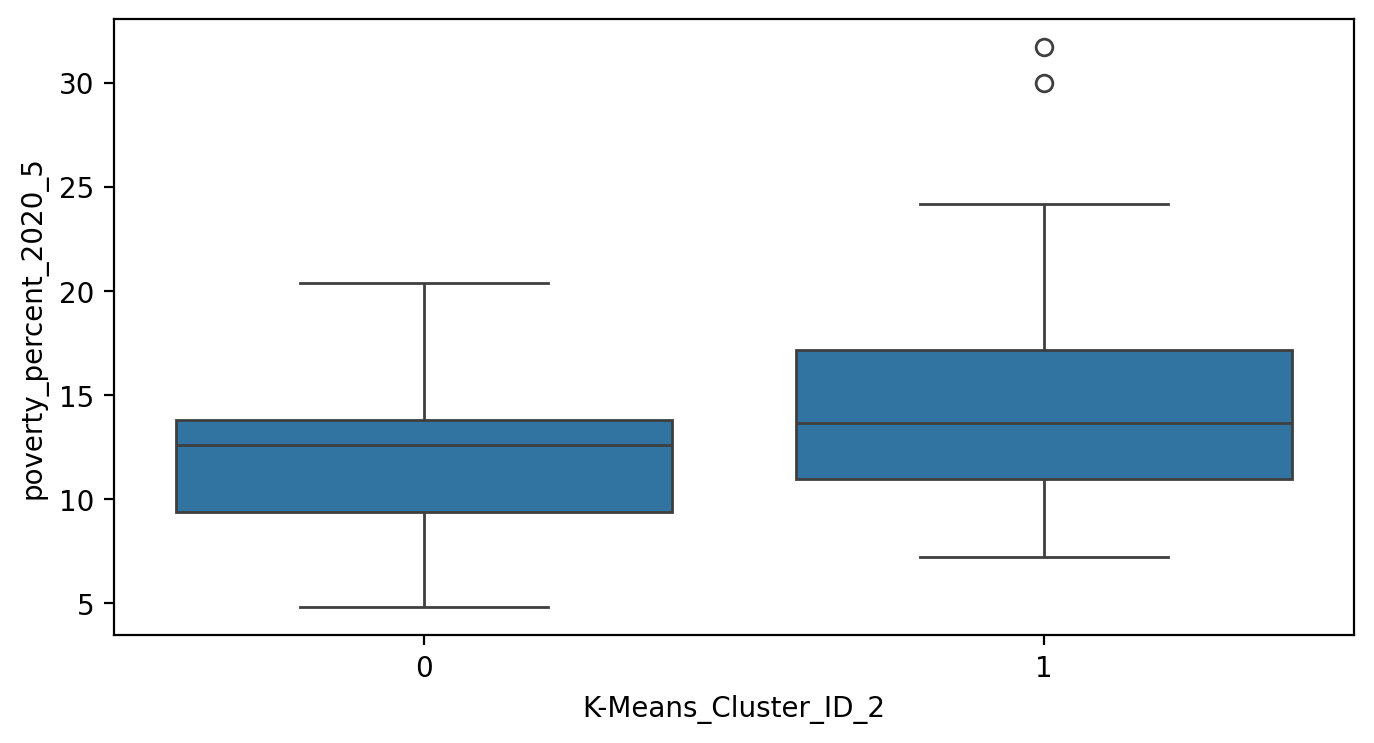

In [205]:
# Зпускаем алгоритм k-means с двумя кластерами.
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X_tsne)
df_merged['K-Means_Cluster_ID_2'] = kmeans.labels_
# Визуализируем кластеры на примере уровня бедности и детской смертности за 2020 год.
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_2', y='2021_0', data=df_merged)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='K-Means_Cluster_ID_2', y='poverty_percent_2020_5', data=df_merged)

In [206]:
K_Means_region = df_merged[df_merged['K-Means_Cluster_ID_2'] == 1]
display(K_Means_region)

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,ноябрь 2021 г._25,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25,K-Means_Cluster_ID_0,K-Means_Cluster_ID_1,K-Means_Cluster_ID_2
6,Амурская область,142.0,124.0,106.0,108.0,111.0,99.0,100.0,118.0,86.0,...,546.0,617.0,592.00,527.00,634.00,529.0,534.00,0,0,1
7,Архангельская область,116.0,118.0,90.0,94.0,80.0,65.0,71.0,46.0,56.0,...,700.0,754.0,654.00,630.00,764.00,656.0,687.00,0,0,1
10,Астраханская область,103.0,73.0,55.0,63.0,62.0,71.0,57.0,79.0,92.0,...,927.0,880.0,781.00,753.00,884.00,676.0,670.00,0,0,1
11,Белгородская область,103.0,92.0,75.0,79.0,80.0,72.0,72.0,67.0,61.0,...,990.0,1028.0,861.00,941.00,956.00,801.0,869.00,0,0,1
12,Брянская область,124.0,109.0,83.0,121.0,99.0,104.0,96.0,67.0,75.0,...,783.0,729.0,707.00,670.00,740.00,589.0,660.00,0,0,1
13,Владимирская область,80.0,58.0,60.0,62.0,46.0,50.0,47.0,38.0,39.0,...,769.0,821.0,691.00,700.00,708.00,660.0,711.00,0,0,1
15,Вологодская область,117.0,104.0,91.0,95.0,91.0,80.0,68.0,65.0,59.0,...,801.0,919.0,753.00,713.00,838.00,667.0,783.00,0,0,1
16,Воронежская область,138.0,179.0,156.0,149.0,154.0,137.0,133.0,132.0,125.0,...,1758.0,1584.0,1342.00,1326.00,1576.00,1309.0,1319.00,0,0,1
20,Еврейская автономная область,49.0,44.0,39.0,45.0,31.0,25.0,28.0,24.0,23.0,...,139.0,133.0,120.00,115.00,136.00,94.0,115.00,0,0,1
21,Забайкальский край,189.0,151.0,138.0,133.0,139.0,109.0,100.0,111.0,100.0,...,981.0,990.0,887.00,905.00,975.00,938.0,917.00,0,0,1


Кластеры уже разделены лучше. Пробуем использовать алгоритм DBSCAN.

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\2521372073.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['DBSCAN_Cluster_ID_1'] = db.labels_


<AxesSubplot: xlabel='DBSCAN_Cluster_ID_1', ylabel='poverty_percent_2020_5'>

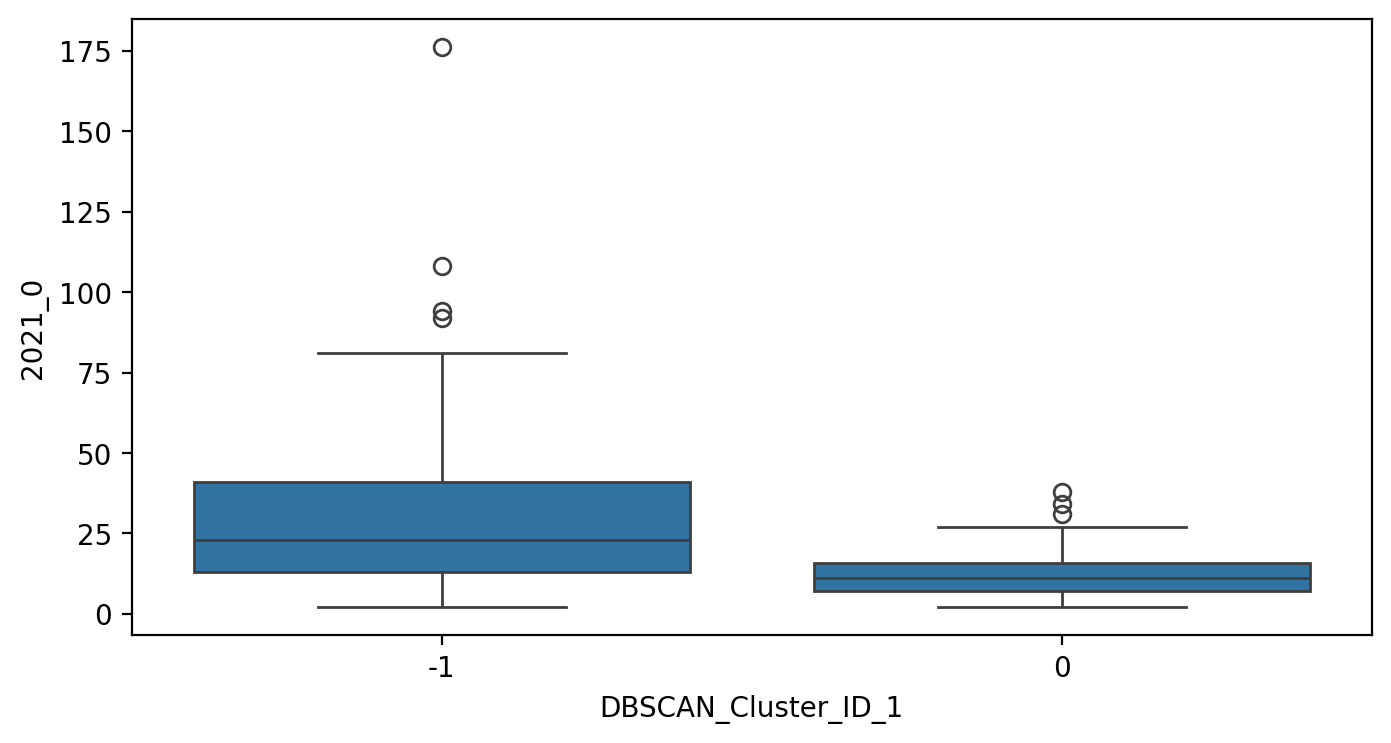

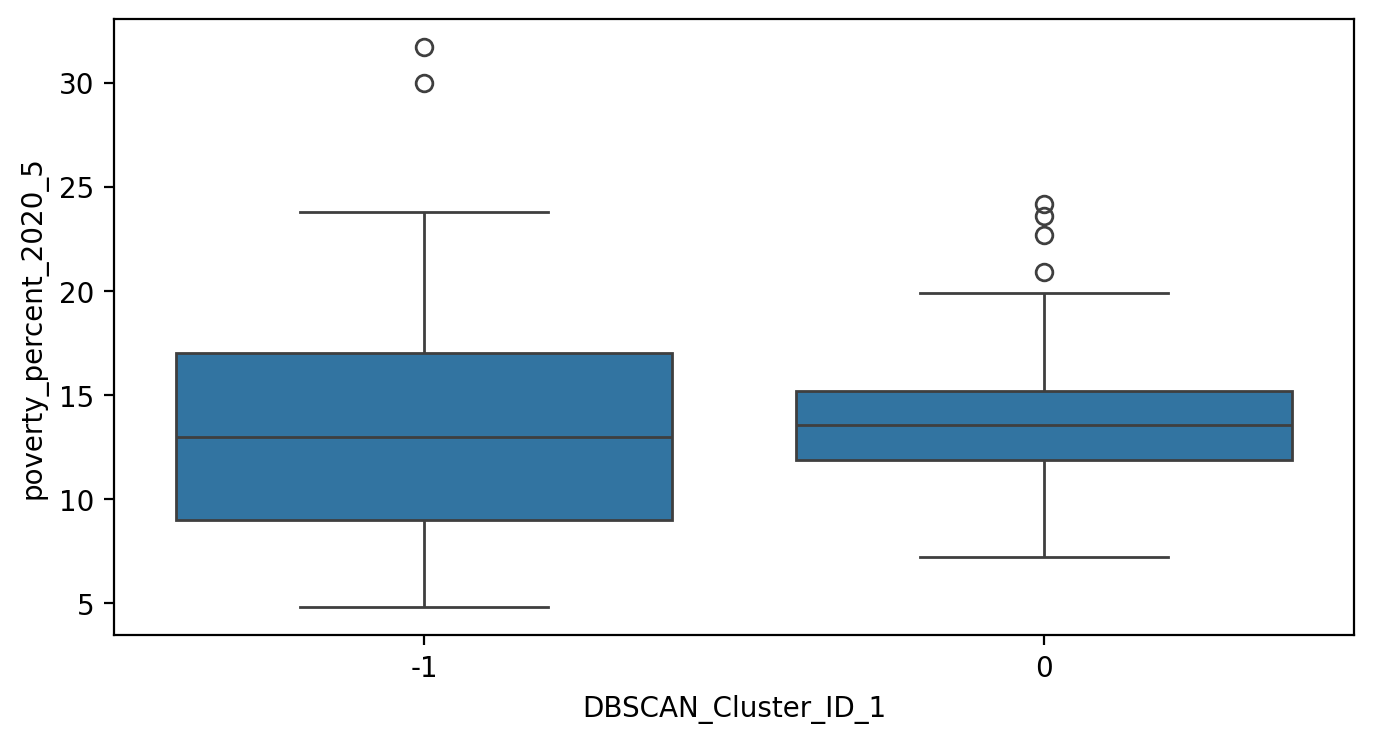

In [207]:
# Запускаем алгоритм.
db = DBSCAN(eps=20, min_samples=10)
db.fit(X_pca)
df_merged['DBSCAN_Cluster_ID_1'] = db.labels_
# Визуализируем кластеры на примере уровня бедности и детской смертности за 2020 год.
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='DBSCAN_Cluster_ID_1', y='2021_0', data=df_merged)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='DBSCAN_Cluster_ID_1', y='poverty_percent_2020_5', data=df_merged)

In [208]:
DBSCAN_region_1 = df_merged[df_merged['DBSCAN_Cluster_ID_1'] == -1]
display(DBSCAN_region_1)

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,декабрь 2021 г._25,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25,K-Means_Cluster_ID_0,K-Means_Cluster_ID_1,K-Means_Cluster_ID_2,DBSCAN_Cluster_ID_1
5,Алтайский край,217.0,245.0,230.0,249.0,226.0,261.0,220.0,213.0,176.0,...,1591.00,1410.00,1433.00,1540.00,1369.0,1488.00,0,0,0,-1
17,Город Москва столица Российской Федерации горо...,111.5,103.5,86.5,94.0,85.0,81.5,72.5,69.5,67.5,...,11014.00,9623.00,9593.99,10171.00,9489.0,9973.00,0,0,0,-1
18,Город Санкт-Петербург город федерального значения,111.5,103.5,86.5,94.0,85.0,81.5,72.5,69.5,67.5,...,4553.00,4024.99,3964.00,4395.00,4013.0,3900.00,0,0,0,-1
23,Иркутская область,281.0,250.0,217.0,227.0,210.0,167.0,154.0,167.0,160.0,...,2064.00,2073.00,1798.00,2207.00,1947.0,2067.00,0,0,0,-1
27,Камчатский край,22.0,22.0,28.0,27.0,21.0,20.0,22.0,20.0,22.0,...,251.00,251.00,256.00,274.00,239.0,254.00,0,0,1,-1
28,Карачаево-Черкесская Республика,59.0,51.0,42.0,52.0,48.0,51.0,61.0,72.0,66.0,...,359.00,328.00,355.00,357.00,396.0,355.00,0,0,1,-1
29,Кемеровская область,139.0,154.0,113.0,124.0,127.0,108.0,99.0,85.0,75.0,...,1819.00,1530.00,1548.00,1858.00,1563.0,1566.00,0,0,0,-1
34,Краснодарский край,504.0,466.0,481.0,510.0,520.0,470.0,394.0,381.0,338.0,...,4896.00,4507.00,4200.00,4850.00,3971.0,3746.00,0,0,0,-1
35,Красноярский край,346.0,315.0,298.0,283.0,239.0,214.0,205.0,206.0,247.0,...,2316.00,2074.00,1959.00,2466.00,1936.0,2217.00,0,0,0,-1
36,Курганская область,174.0,136.0,155.0,181.0,121.0,123.0,96.0,77.0,83.0,...,573.00,587.00,484.00,570.00,498.0,508.00,0,0,1,-1


Алгоритм выделил два кластера, один из которых заполнил выбросами. Можно предположить, что интересующие нас группы находятся в нём, но сам кластер нам не подходит, так как он, помимо наиболее нуждающихся, содержит наименее нуждающихся в помощи малообеспеченным.

In [209]:
cluster_labels = db.labels_
silhouette_avg = silhouette_score(X_pca, cluster_labels)
display(silhouette_avg)

0.19828861442954537

Качество ещё сильнее упало. Пробуем DBSCAN ещё раз, но с данными X_tsne.

C:\Users\Aleksey\AppData\Local\Temp\ipykernel_6612\4198617361.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_merged['DBSCAN_Cluster_ID_2'] = db.labels_


<AxesSubplot: xlabel='DBSCAN_Cluster_ID_2', ylabel='poverty_percent_2020_5'>

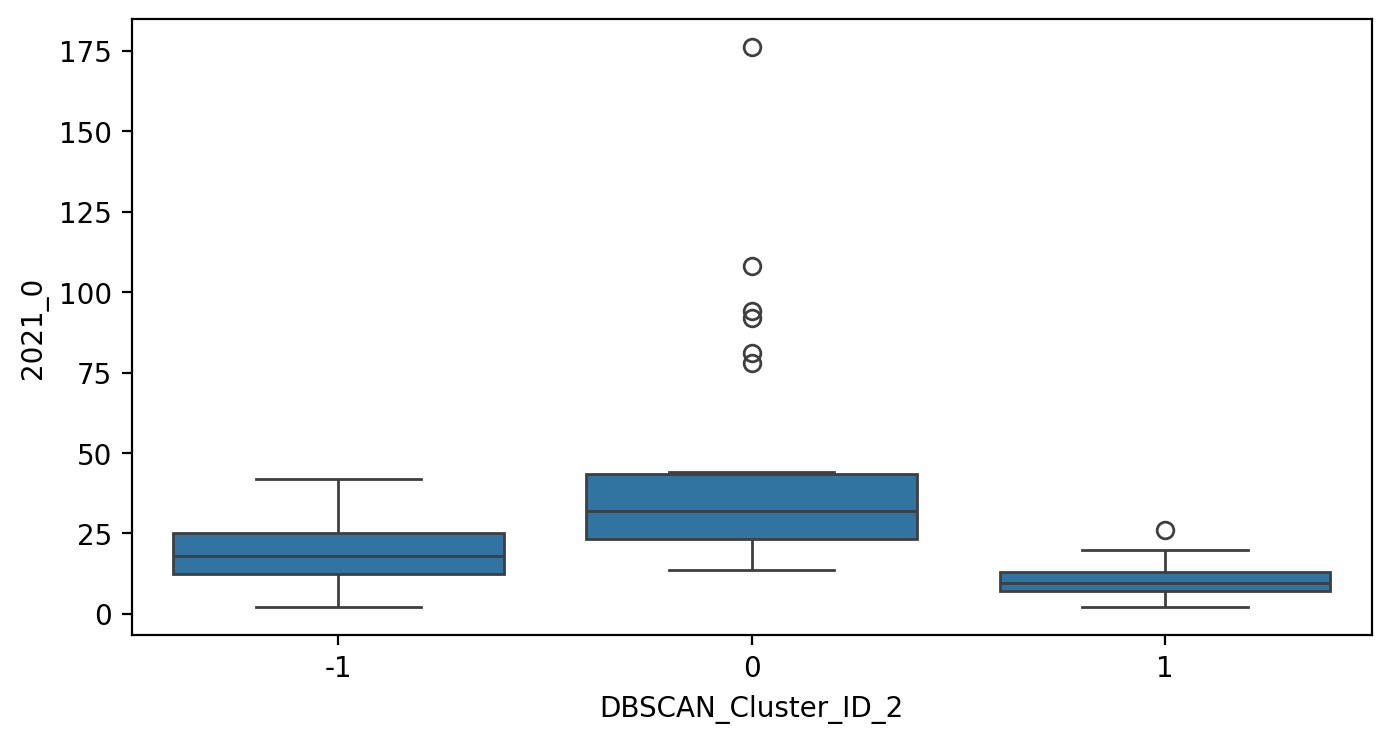

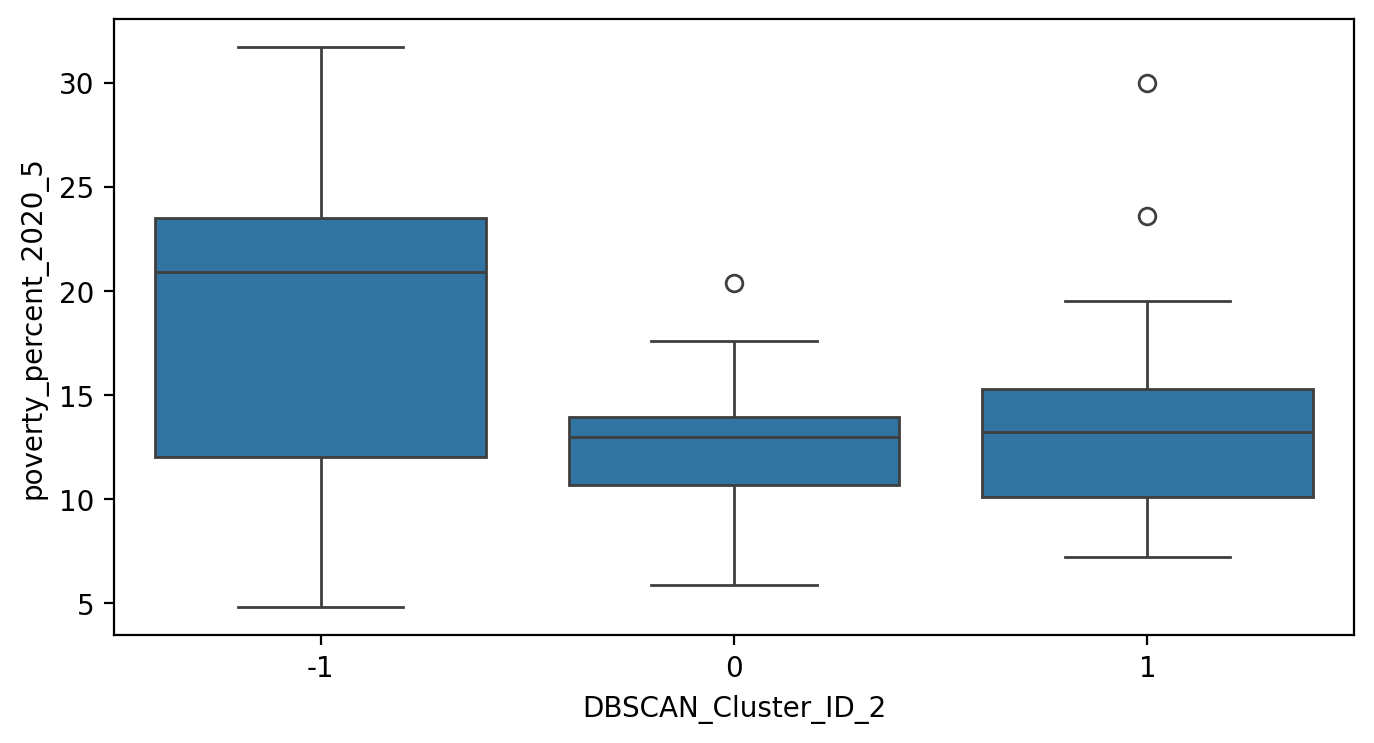

In [210]:
# Запускаем алгоритм.
db = DBSCAN(eps=70, min_samples=10)
db.fit(X_tsne)
df_merged['DBSCAN_Cluster_ID_2'] = db.labels_
# Визуализируем кластеры на примере уровня бедности и детской смертности за 2020 год.
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='DBSCAN_Cluster_ID_2', y='2021_0', data=df_merged)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='DBSCAN_Cluster_ID_2', y='poverty_percent_2020_5', data=df_merged)

Алгоритм выделил 3 кластера: Наиболее нуждающиеся, средняя группа и наименее нуждающиеся.

In [211]:
DBSCAN_region_2 = df_merged[df_merged['DBSCAN_Cluster_ID_2'] == -1]
display(DBSCAN_region_2)

,region,1990_0,1991_0,1992_0,1993_0,1994_0,1995_0,1996_0,1997_0,1998_0,...,январь 2022 г._25,февраль 2022 г._25,март 2022 г._25,апрель 2022 г._25,май 2022 г._25,K-Means_Cluster_ID_0,K-Means_Cluster_ID_1,K-Means_Cluster_ID_2,DBSCAN_Cluster_ID_1,DBSCAN_Cluster_ID_2
21,Забайкальский край,189.0,151.0,138.0,133.0,139.0,109.0,100.0,111.0,100.0,...,887.0,905.00,975.00,938.0,917.0,0,0,1,0,-1
24,Кабардино-Балкарская Республика,127.0,123.0,102.0,110.0,109.0,76.0,86.0,82.0,87.0,...,757.0,756.00,857.00,798.0,780.0,0,0,1,0,-1
28,Карачаево-Черкесская Республика,59.0,51.0,42.0,52.0,48.0,51.0,61.0,72.0,66.0,...,328.0,355.00,357.00,396.0,355.0,0,0,1,-1,-1
54,Республика Адыгея,51.0,43.0,46.0,52.0,44.0,44.0,36.0,45.0,31.0,...,335.0,334.00,384.00,331.0,283.0,0,0,1,-1,-1
55,Республика Алтай,85.0,57.0,66.0,60.0,59.0,57.0,62.0,48.0,53.0,...,262.0,219.00,259.00,218.0,202.0,0,0,1,-1,-1
57,Республика Бурятия,191.0,148.0,110.0,105.0,90.0,87.0,76.0,100.0,98.0,...,942.0,831.00,993.99,897.0,851.0,0,0,1,0,-1
60,Республика Калмыкия,53.0,45.0,51.0,62.0,50.0,38.0,28.0,40.0,33.0,...,199.0,199.00,227.00,183.0,172.0,0,0,1,0,-1
69,Республика Тыва,148.0,140.0,147.0,121.0,93.0,100.0,109.0,106.0,83.0,...,450.0,462.00,584.00,432.0,513.0,0,0,1,-1,-1
84,Тюменская область,268.0,267.0,217.0,208.0,176.0,200.0,147.0,184.0,172.0,...,3431.0,3203.00,3888.00,3394.0,3589.0,1,1,0,-1,-1
91,Ханты-Мансийский АО,44.0,44.0,40.0,46.0,25.0,47.0,31.0,34.0,33.0,...,1420.0,1412.00,1714.00,1493.0,1589.0,1,1,0,-1,-1


In [212]:
cluster_labels = db.labels_
silhouette_avg = silhouette_score(X_tsne, cluster_labels)
display(silhouette_avg)

0.49591446

Качество уже лучше. Нас устраивает такое разделение на кластеры. Переходим к описанию группы населения.

## <center> 3.2 Описание групп населения </center>

In [213]:
X_DBSCAN =  DBSCAN_region_2.drop('region',axis =1)

In [214]:
# Смотрим значения для описания группы населения, встречающихся с бедностью.
display(X_DBSCAN['poverty_percent_2020_5'].describe().round(2).to_frame())
display(X_DBSCAN['Дети в возрасте до 16 лет_14'].describe().round(2).to_frame())
display(X_DBSCAN['Население старше трудоспособного возраста_14'].describe().round(2).to_frame())
display(X_DBSCAN['Население трудоспособного возраста_14'].describe().round(2).to_frame())
display(X_DBSCAN['2020_6'].describe().round(2).to_frame())
display(X_DBSCAN['2020_9'].describe().round(2).to_frame())

,poverty_percent_2020_5
count,11.00
mean,18.52
std,8.10
min,4.80
25%,12.05
50%,20.90
75%,23.50
max,31.70


,Дети в возрасте до 16 лет_14
count,11.00
mean,41.70
std,8.28
min,27.60
25%,34.85
50%,44.50
75%,45.30
max,55.60


,Население старше трудоспособного возраста_14
count,11.00
mean,3.87
std,2.48
min,0.30
25%,2.10
50%,3.70
75%,6.05
max,7.20


,Население трудоспособного возраста_14
count,11.00
mean,54.45
std,7.10
min,42.90
25%,49.95
50%,52.60
75%,58.35
max,65.90


,2020_6
count,11.00
mean,22.85
std,5.85
min,12.60
25%,20.00
50%,23.80
75%,26.00
max,34.40


,2020_9
count,11.00
mean,51176.36
std,26814.82
min,29865.00
25%,32087.00
50%,41800.00
75%,62895.50
max,111216.00


В кластер попал регион не из уязвимой группы населения, однако по информации можно примерно описать искомую группу.

Группы населения, встречающиеся с бедностью имеют среднемесячную номинальную начисленную заработную плату от 29865 до 41800 рублей, \
состоят в основном из людей трудоспособного возраста, которые проживают в регионах с процентом выделенных расходов на социальную политику от 12.6% до 23,8%.

## <center> 3.3 Определение зависимостей </center>

Последним этапом нам осталось ответить на ряд вопросов по поводу зависимости различных признаков друг от друга.

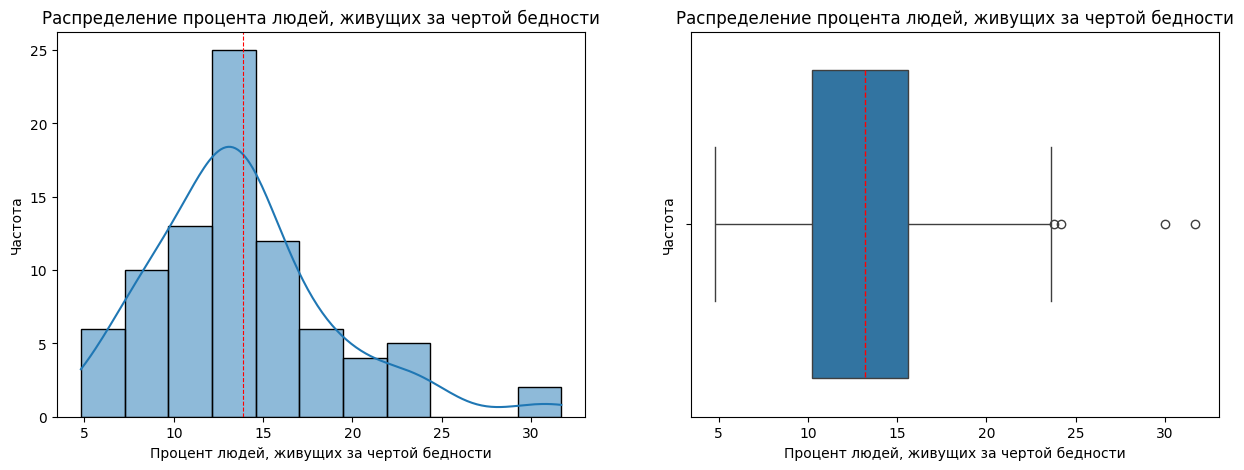

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Визуализируем распределение процента бедности.
sns.histplot(df_merged['poverty_percent_2020_5'], kde=True, ax=axes[0])
axes[0].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Частота')
axes[0].set_title('Распределение процента людей, живущих за чертой бедности')
axes[0].axvline(df_merged['poverty_percent_2020_5'].mean(), color='red', linestyle='--', linewidth=0.8)
sns.boxplot(df_merged['poverty_percent_2020_5'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Частота')
axes[1].set_title('Распределение процента людей, живущих за чертой бедности')

plt.show()

Влияет ли число детей, пенсионеров и других социально уязвимых
групп на уровень бедности в регионе?

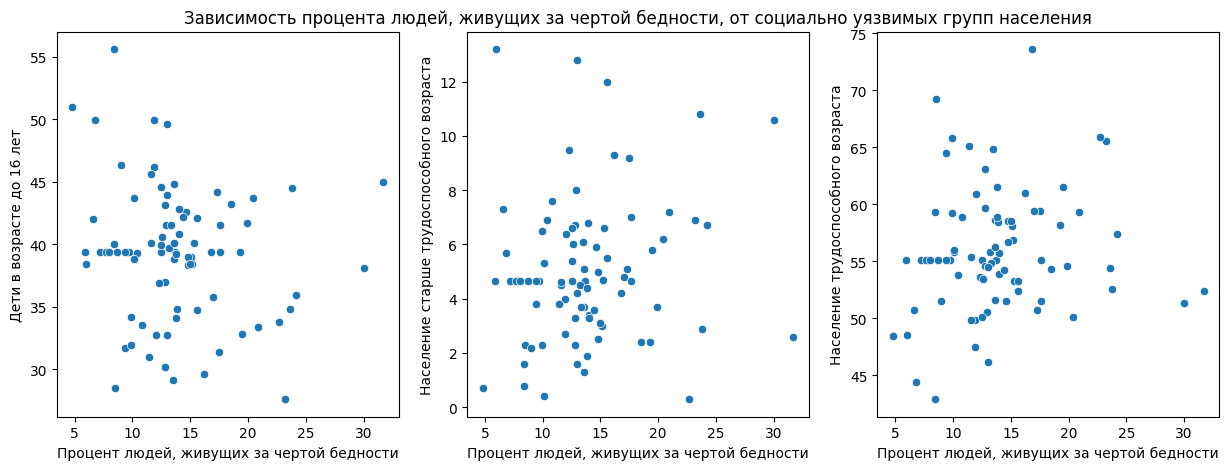

In [216]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='Дети в возрасте до 16 лет_14', ax=axes[0])
axes[0].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Дети в возрасте до 16 лет')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='Население старше трудоспособного возраста_14', ax=axes[1])
axes[1].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Население старше трудоспособного возраста')
axes[1].set_title('Зависимость процента людей, живущих за чертой бедности, от социально уязвимых групп населения')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='Население трудоспособного возраста_14', ax=axes[2])
axes[2].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Население трудоспособного возраста')
plt.show()


По визуализации сложно определить какую-либо зависимость в данных. Для определения зависимости будем использовать корреляцию Пирсона. Зависимость будет считаться статистически значимой, если p-value будет менее 0.05.

In [217]:
#Считаем p-value коэффицента корреляции между числом детей, пенсионеров, других социально уязвимых групп
# и уровенем бедности в регионе.
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['Дети в возрасте до 16 лет_14']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['Население старше трудоспособного возраста_14']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['Население трудоспособного возраста_14']))

PearsonRResult(statistic=-0.16229125987809467, pvalue=0.14268706107664156)

PearsonRResult(statistic=0.13920777414169747, pvalue=0.20943123268008856)

PearsonRResult(statistic=0.13133079806098608, pvalue=0.23662328941269553)

Нет статистической значимости, так как значения pvalue не меньше 0.05. \
 Делаем вывод, что число социально уязвимых групп не влияет на уровень бедности в регионе.

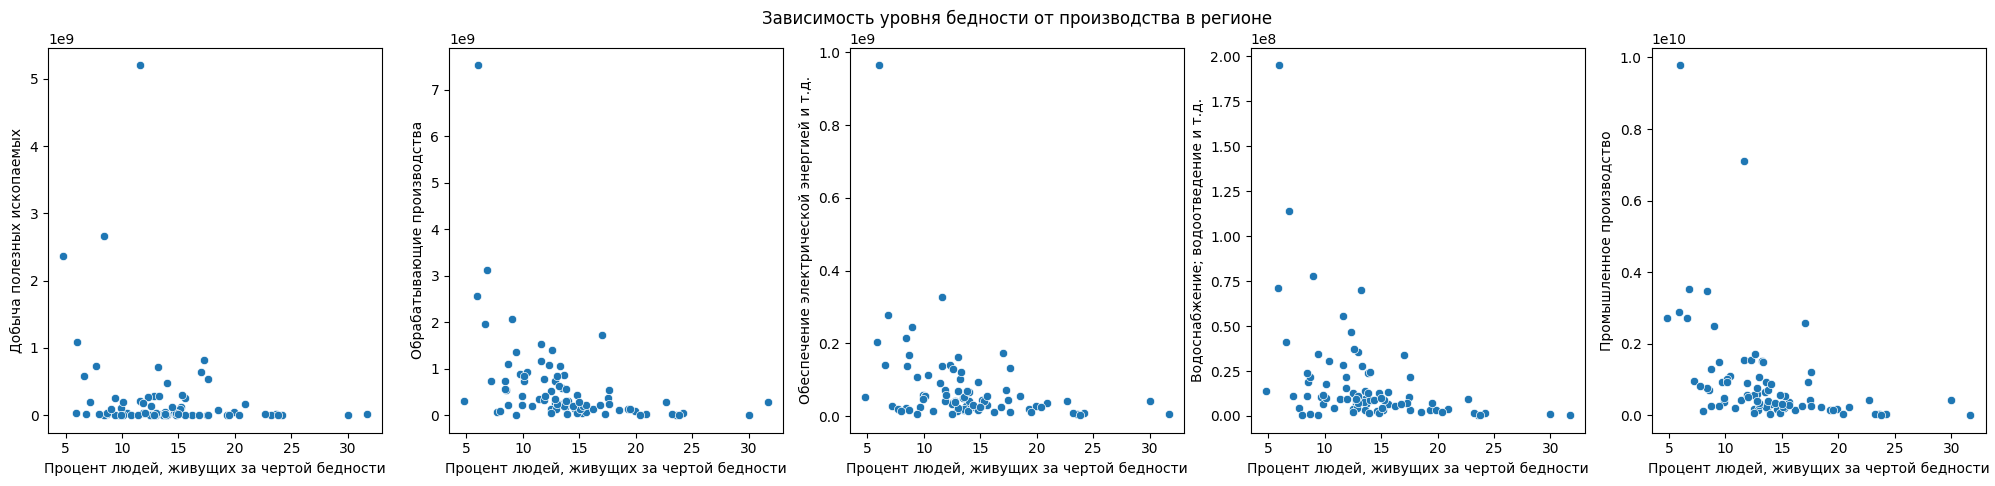

In [218]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_1_19', ax=axes[0])
axes[0].set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Добыча полезных ископаемых')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_2_19', ax=axes[1])
axes[1].set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Обрабатывающие производства')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_3_19', ax=axes[2])
axes[2].set(xlabel='Процент людей, живущих за чертой бедности', ylabel='Обеспечение электрической энергией и т.д.')
axes[2].set_title('Зависимость уровня бедности от производства в регионе')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_4_19', ax=axes[3])
axes[3].set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Водоснабжение; водоотведение и т.д.')
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_5_19', ax=axes[4])
axes[4].set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Промышленное производство')

plt.show()

По визуализации можно предположить некую зависимость. Определяем статистическую значимость.

In [219]:
# Считаем p-value коэффицента корреляции между производством, потреблением в регионе
# и уровенем бедности в регионе.
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_1_19']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_2_19']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_3_19']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_4_19']))
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_5_19']))

PearsonRResult(statistic=-0.2115427377007137, pvalue=0.0548824864041489)

PearsonRResult(statistic=-0.41424412356986234, pvalue=9.89594495687143e-05)

PearsonRResult(statistic=-0.34891252042756654, pvalue=0.0012259548180427577)

PearsonRResult(statistic=-0.40055755178138885, pvalue=0.00017521732377644093)

PearsonRResult(statistic=-0.4131691528018856, pvalue=0.00010359394410450789)

Статистически значимая связь есть у обеспечения электрической энергией,водоснабжения и промышленность, так как у них p-value меньше 0.05.

[Text(0.5, 0, 'Процент людей, живущих за чертой бедности'),
 Text(0, 0.5, 'Оборот розничной торговли')]

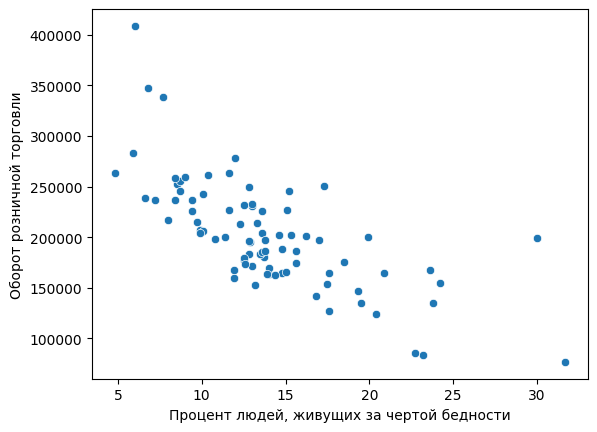

In [220]:
sns.scatterplot(data=df_merged, x='poverty_percent_2020_5', y='2020_20').set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Оборот розничной торговли')

График рассеяния напоминает отрицательную корреляцию. Проверяем её статистическю значимость.

In [221]:
# Считаем p-value коэффицента корреляции между оборотом розничной торговли и уровнем бедности.
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_20']))

PearsonRResult(statistic=-0.7074447249373372, pvalue=7.639194087451368e-14)

Корреляция оказалась статистически незначительной.

Дополнительно проверим зависимость уровня бедности в регионе от расходов на социальную политику в регионе.

[Text(0.5, 0, 'Процент людей, живущих за чертой бедности'),
 Text(0, 0.5, 'Расходы на социальную политику')]

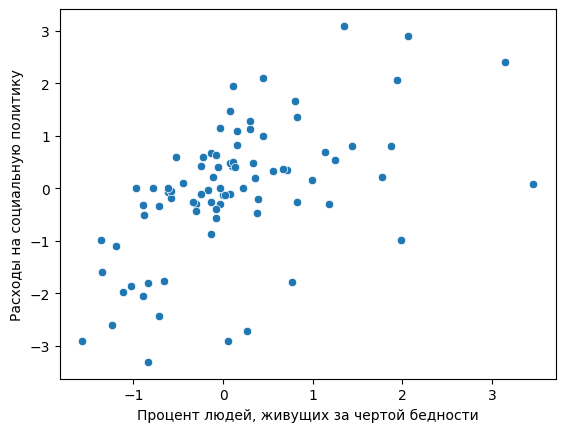

In [222]:
sns.scatterplot(data=X_scaled_df, x='poverty_percent_2020_5', y='2020_6').set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Расходы на социальную политику')

По графику можно предположить положительную зависимость. Проверяем значимость.

In [223]:
# Считаем p-value коэффицента корреляции между расходами на социальную политику и уровнем бедности.
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_6']))

PearsonRResult(statistic=0.5529181887089174, pvalue=5.9526192985641725e-08)

Зависимость оказалась не статистически значимой.

Так же проверим зависимость уровня социального неблагополучия со среднемесячной номинальной начисленной заработной платой.

[Text(0.5, 0, 'Процент людей, живущих за чертой бедности'),
 Text(0, 0.5, 'Среднемесячная номинальная начисленная заработная плата')]

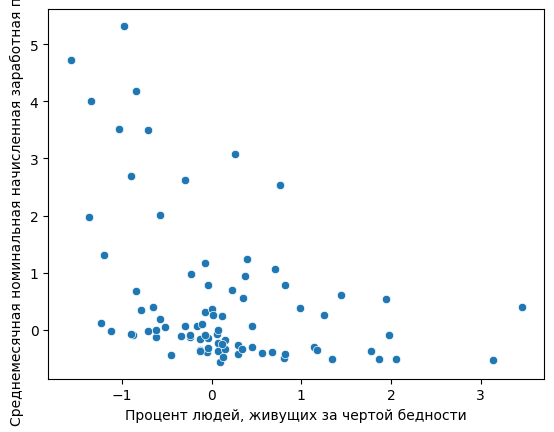

In [225]:
sns.scatterplot(data=X_scaled_df, x='poverty_percent_2020_5', y='2020_9').set(xlabel='Процент людей, живущих за чертой бедности',ylabel='Среднемесячная номинальная начисленная заработная плата')

Можно заметить некоторую отрицательную корреляцию. Проверяем статистическую значимость.

In [226]:
# Считаем p-value коэффицента корреляции между заработными платами и уровнем бедности.
display(pearsonr(df_merged['poverty_percent_2020_5'], df_merged['2020_9']))

PearsonRResult(statistic=-0.40326894831730353, pvalue=0.00015677231728354428)

Зависимость является статистически значимой, можем делать вывод о зависимости между уровнем бедности и средними заработными платами.

Завершив все этапы проекта нам удалось:
* кластезировать регионы России и выделить кластер наиболее нуждающихся в помощи малообеспеченным;
* описать группы населения, сталкивающиеся с бедностью, которые представляют из себя в среднем трудоспособных граждан с зарплатой до 40 тысяч рублей;
* определить звисимость уровня бедности от размера заработных плат и некоторых сфер производства: обеспечение электрической энергией,водоснабжение и промышленность.